<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8010/blob/main/Semana_15_DeepLearning_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales Convolucionales


**By Neuromatch Academy**

__Content creators:__ Dawn Estes McKnight, Richard Gerum, Cassidy Pirlot, Rohan Saha, Liam Peet-Pare, Saeed Najafi, Alona Fyshe

__Content reviewers:__ Saeed Salehi, Lily Cheng, Yu-Fang Yang, Polina Turishcheva, Bettina Hein, Kelson Shilling-Scrivo

__Content editors:__ Gagana B, Nina Kudryashova, Anmol Gupta, Xiaoxiong Lin, Spiros Chavlis

__Production editors:__ Alex Tran-Van-Minh, Gagana B, Spiros Chavlis

<br>

*Basado en material de:* Konrad Kording, Hmrishav Bandyopadhyay, Rahul Shekhar, Tejas Srivastava

# Configuración

## Instalar dependencias

In [13]:
# @title Install dependencies
!pip install Pillow --quiet

In [14]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_dl",
            "user_key": "f379rz8y",
        },
    ).render()


feedback_prefix = "W2D2_T1"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.0 MB/s eta 0:00:00


In [15]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # Interactive display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt

plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

In [16]:
# @title Helper functions
from scipy.signal import correlate2d
import zipfile, gzip, shutil, tarfile


def download_data(fname, folder, url, tar):
  """
  Data downloading from OSF.

  Args:
    fname : str
      The name of the archive
    folder : str
      The name of the destination folder
    url : str
      The download url
    tar : boolean
      `tar=True` the archive is `fname`.tar.gz, `tar=False` is `fname`.zip

  Returns:
    Nothing.
  """

  if not os.path.exists(folder):
    print(f'\nDownloading {folder} dataset...')
    r = requests.get(url, allow_redirects=True)
    with open(fname, 'wb') as fh:
      fh.write(r.content)
    print(f'\nDownloading {folder} completed.')

    print('\nExtracting the files...\n')
    if not tar:
      with zipfile.ZipFile(fname, 'r') as fz:
        fz.extractall()
    else:
      with tarfile.open(fname) as ft:
        ft.extractall()
    # Remove the archive
    os.remove(fname)

    # Extract all .gz files
    foldername = folder + '/raw/'
    for filename in os.listdir(foldername):
      # Remove the extension
      fname = filename.replace('.gz', '')
      # Gunzip all files
      with gzip.open(foldername + filename, 'rb') as f_in:
        with open(foldername + fname, 'wb') as f_out:
          shutil.copyfileobj(f_in, f_out)
          os.remove(foldername+filename)
  else:
    print(f'{folder} dataset has already been downloaded.\n')


def check_shape_function(func, image_shape, kernel_shape):
  """
  Helper function to check shape implementation

  Args:
    func: f.__name__
      Function name
    image_shape: tuple
      Image shape
    kernel_shape: tuple
      Kernel shape

  Returns:
    Nothing
  """
  correct_shape = correlate2d(np.random.rand(*image_shape), np.random.rand(*kernel_shape), "valid").shape
  user_shape = func(image_shape, kernel_shape)
  if correct_shape != user_shape:
    print(f"❌ Your calculated output shape is not correct.")
  else:
    print(f"✅ Output for image_shape: {image_shape} and kernel_shape: {kernel_shape}, output_shape: {user_shape}, is correct.")


def check_conv_function(func, image, kernel):
  """
  Helper function to check conv_function

  Args:
    func: f.__name__
      Function name
    image: np.ndarray
      Image matrix
    kernel_shape: np.ndarray
      Kernel matrix

  Returns:
    Nothing
  """
  solution_user = func(image, kernel)
  solution_scipy = correlate2d(image, kernel, "valid")
  result_right = (solution_user == solution_scipy).all()
  if result_right:
    print("✅ The function calculated the convolution correctly.")
  else:
    print("❌ The function did not produce the right output.")
    print("For the input matrix:")
    print(image)
    print("and the kernel:")
    print(kernel)
    print("the function returned:")
    print(solution_user)
    print("the correct output would be:")
    print(solution_scipy)


def check_pooling_net(net, device='cpu'):
  """
  Helper function to check pooling output

  Args:
    net: nn.module
      Net instance
    device: string
      GPU/CUDA if available, CPU otherwise.

  Returns:
    Nothing
  """
  x_img = emnist_train[x_img_idx][0].unsqueeze(dim=0).to(device)
  output_x = net(x_img)
  output_x = output_x.squeeze(dim=0).detach().cpu().numpy()

  right_output = [
      [0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
      0.000000, 0.000000, 0.000000, 0.000000, 0.000000],
      [0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
      0.000000, 0.000000, 0.000000, 0.000000, 0.000000],
      [9.309552, 1.6216984, 0.000000, 0.000000, 0.000000, 0.000000, 2.2708383,
      2.6654134, 1.2271233, 0.000000, 0.000000, 0.000000],
      [12.873457, 13.318945, 9.46229, 4.663746, 0.000000, 0.000000, 1.8889914,
      0.31068993, 0.000000, 0.000000, 0.000000, 0.000000],
      [0.000000, 8.354934, 10.378724, 16.882853, 18.499334, 4.8546696, 0.000000,
      0.000000, 0.000000, 6.29296, 5.096506, 0.000000],
      [0.000000, 0.000000, 0.31068993, 5.7074604, 9.984148, 4.12916, 8.10037,
      7.667609, 0.000000, 0.000000, 1.2780352, 0.000000],
      [0.000000, 2.436305, 3.9764223, 0.000000, 0.000000, 0.000000, 12.98801,
      17.1756, 17.531992, 11.664275, 1.5453291, 0.000000],
      [4.2691708, 2.3217516, 0.000000, 0.000000, 1.3798618, 0.05612564, 0.000000,
      0.000000, 11.218788, 16.360992, 13.980816, 8.354935],
      [1.8126211, 0.000000, 0.000000, 2.9199777, 3.9382377, 0.000000, 0.000000,
      0.000000, 0.000000, 0.000000, 6.076582, 10.035061],
      [0.000000, 0.92164516, 4.434638, 0.7816348, 0.000000, 0.000000, 0.000000,
      0.000000, 0.000000, 0.000000, 0.000000, 0.83254766],
      [0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
      0.000000, 0.000000, 0.000000, 0.000000, 0.000000],
      [0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
      0.000000, 0.000000, 0.000000, 0.000000, 0.000000]
  ]

  right_shape = (3, 12, 12)

  if output_x.shape != right_shape:
    print(f"❌ Your output does not have the right dimensions. Your output is {output_x.shape} the expected output is {right_shape}")
  elif (output_x[0] != right_output).all():
    print("❌ Your output is not right.")
  else:
    print("✅ Your network produced the correct output.")


# Just returns accuracy on test data
def test(model, device, data_loader):
  """
  Test function

  Args:
    net: nn.module
      Net instance
    device: string
      GPU/CUDA if available, CPU otherwise.
    data_loader: torch.loader
      Test loader

  Returns:
    acc: float
      Test accuracy
  """
  model.eval()
  correct = 0
  total = 0
  for data in data_loader:
    inputs, labels = data
    inputs = inputs.to(device).float()
    labels = labels.to(device).long()

    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  acc = 100 * correct / total
  return f"{acc}%"

In [17]:
# @title Plotting Functions

def display_image_from_greyscale_array(matrix, title):
  """
  Display image from greyscale array

  Args:
    matrix: np.ndarray
      Image
    title: string
      Title of plot

  Returns:
    Nothing
  """
  _matrix = matrix.astype(np.uint8)
  _img = Image.fromarray(_matrix, 'L')
  plt.figure(figsize=(3, 3))
  plt.imshow(_img, cmap='gray', vmin=0, vmax=255) # Using 220 instead of 255 so the examples show up better
  plt.title(title)
  plt.axis('off')


def make_plots(original, actual_convolution, solution):
  """
  Function to build original image/obtained solution and actual convolution

  Args:
    original: np.ndarray
      Image
    actual_convolution: np.ndarray
      Expected convolution output
    solution: np.ndarray
      Obtained convolution output

  Returns:
    Nothing
  """
  display_image_from_greyscale_array(original, "Original Image")
  display_image_from_greyscale_array(actual_convolution, "Convolution result")
  display_image_from_greyscale_array(solution, "Your solution")


def plot_loss_accuracy(train_loss, train_acc,
                       validation_loss, validation_acc):
  """
  Code to plot loss and accuracy

  Args:
    train_loss: list
      Log of training loss
    validation_loss: list
      Log of validation loss
    train_acc: list
      Log of training accuracy
    validation_acc: list
      Log of validation accuracy

  Returns:
    Nothing
  """
  epochs = len(train_loss)
  fig, (ax1, ax2) = plt.subplots(1, 2)
  ax1.plot(list(range(epochs)), train_loss, label='Training Loss')
  ax1.plot(list(range(epochs)), validation_loss, label='Validation Loss')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.set_title('Epoch vs Loss')
  ax1.legend()

  ax2.plot(list(range(epochs)), train_acc, label='Training Accuracy')
  ax2.plot(list(range(epochs)), validation_acc, label='Validation Accuracy')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Accuracy')
  ax2.set_title('Epoch vs Accuracy')
  ax2.legend()
  fig.set_size_inches(15.5, 5.5)

In [18]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [19]:
# @title Set random seed

# @markdown Executing `set_seed(seed=seed)` you are setting the seed

# For DL its critical to set the random seed so that students can have a
# baseline to compare their results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

# Call `set_seed` function in the exercises to ensure reproducibility.
import random
import torch

def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness.
  NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [20]:
# @title Set device (GPU or CPU). Execute `set_device()`
# especially if torch modules used.

# Inform the user if the notebook uses GPU or CPU.

def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, "
        "if possible, in the menu under `Runtime` -> "
        "`Change runtime type.`  select `GPU` ")
  else:
    print("GPU is enabled in this notebook.")

  return device

In [21]:
SEED = 2021
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2021 has been set.
GPU is enabled in this notebook.


# Librerías

In [22]:
# Imports
import time
import torch
import scipy.signal
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from tqdm.notebook import tqdm, trange
from PIL import Image

# Sección 1: Convoluciones y Detección de Aristas

Las convoluciones es un aspecto fundamental de las CNNs.

La convolución involucra:


*   Desplazamiento del kernel a través de la imagen
*   Producto elemento a elemento (producto Hadamard), colocando aquellos productos juntos.


<img src="https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D2_ConvnetsAndDlThinking/static/correlation.svg">

Adopted from A. Zhang, Z. C. Lipton, M. Li and A. J. Smola, _[Dive into Deep Learning](http://d2l.ai/chapter_convolutional-neural-networks/conv-layer.html)_.

<br>




# Visualización de la Convolución

In [23]:
# @markdown *Run this cell to enable the widget!*

from IPython.display import HTML

id_html = 2
url = f'https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D2_ConvnetsAndDlThinking/static/interactive_demo{id_html}.html'
run_demo = True  # @param {type:"boolean"}
if run_demo:
  display(HTML(url))

En este caso, la convolución se conoce como correlación cruzada (de ahí el uso de `scipy.signal.correlate2d` en el siguiente ejercicio

# Ejercicio de Código #1: Convolución de un Simple Kernel

Convolución consiste en multiplicar repetidamente una matriz conocda como kernel o filtro con una matriz más grande (imagen).

Considera la siguiente imagen y kernel:

\begin{align}
\textbf{Image} &=
\begin{bmatrix}0 & 200 & 200 \\0 & 0 & 200 \\ 0 & 0 & 0
\end{bmatrix} \\ \\
\textbf{Kernel} &=
\begin{bmatrix} \frac{1}{4} &\frac{1}{4} \\\frac{1}{4} & \frac{1}{4}
\end{bmatrix}
\end{align}


Desarrolla (a mano) las operaciones necesarias para convolucionar el kernel con la imagen de arriba. Después, ingresa tus resultados en la sección "solución" en el código de abajo. Piensa en qué está haciendo el kernel específico sobre la imagen original.

```python
def conv_check():
  """
  Demostración de operación de convolución

  Args:
    None

  Returns:
    original: np.ndarray
      Image
    actual_convolution: np.ndarray
      Expected convolution output
    solution: np.ndarray
      Obtained convolution output
    kernel: np.ndarray
      Kernel
  """
  ####################################################################
  # Llena el código faltante abajo (los elementos de la matriz),
  # luego elimina o comenta la línea debajo para probar tu función
  raise NotImplementedError("Crea la matriz solución, luego elimina esto")
  ####################################################################
  # Escribe la solución del arreglo e invoca a la función para verificarla!
  solution = ...

  original = np.array([
                       [0, 200, 200],
                       [0, 0, 200],
                       [0, 0, 0]
                       ])

  kernel = np.array([
                     [0.25, 0.25],
                     [0.25, 0.25]
                     ])

  actual_convolution = scipy.signal.correlate2d(original, kernel, mode="valid")

  if (solution == actual_convolution).all():
    print("✅ ¡Tu solución es correcta!\n")
  else:
    print("❌ Tu solución es incorrecta.\n")

  return original, kernel, actual_convolution, solution



## Quita este comentario para testear tu solución!
# original, kernel, actual_convolution, solution = conv_check()
# make_plots(original, actual_convolution, solution)
```

In [24]:
# Aquí debes copiar el código con tu solució para "Ejercicio de Código #1: Convolución de un Simple Kernel"

solution1 = (0 * 1/4) + (200*1/4) + (0 * 1/4) + (0 * 1/4)
solution2 = (200 * 1/4) + (200*1/4) + (0 * 1/4) + (200 * 1/4)
solution3 = (0 * 1/4) + (0*1/4) + (0 * 1/4) + (0 * 1/4)
solution4 = (0 * 1/4) + (200*1/4) + (0 * 1/4) + (0 * 1/4)
solution = np.array([[solution1, solution2], [solution3, solution4]])
print(solution)



def conv_check():
  """
  Demostración de operación de convolución

  Args:
    None

  Returns:
    original: np.ndarray
      Image
    actual_convolution: np.ndarray
      Expected convolution output
    solution: np.ndarray
      Obtained convolution output
    kernel: np.ndarray
      Kernel
  """
  ####################################################################
  # Llena el código faltante abajo (los elementos de la matriz),
  # luego elimina o comenta la línea debajo para probar tu función
  #raise NotImplementedError("Crea la matriz solución, luego elimina esto")
  ####################################################################
  # Escribe la solución del arreglo e invoca a la función para verificarla!


  solution1 = (0 * 1/4) + (200*1/4) + (0 * 1/4) + (0 * 1/4)
  solution2 = (200 * 1/4) + (200*1/4) + (0 * 1/4) + (200 * 1/4)
  solution3 = (0 * 1/4) + (0*1/4) + (0 * 1/4) + (0 * 1/4)
  solution4 = (0 * 1/4) + (200*1/4) + (0 * 1/4) + (0 * 1/4)

  solution = np.array([[solution1, solution2], [solution3, solution4]])

  original = np.array([
                       [0, 200, 200],
                       [0, 0, 200],
                       [0, 0, 0]
                       ])

  kernel = np.array([
                     [0.25, 0.25],
                     [0.25, 0.25]
                     ])

  actual_convolution = scipy.signal.correlate2d(original, kernel, mode="valid")

  if (solution == actual_convolution).all():
    print("✅ ¡Tu solución es correcta!\n")
  else:
    print("❌ Tu solución es incorrecta.\n")

  return original, kernel, actual_convolution, solution


[[ 50. 150.]
 [  0.  50.]]


In [10]:
original, kernel, actual_convolutional, solution = conv_check()

✅ ¡Tu solución es correcta!



# Ejercicio de Código #2: Tamaño de Salida de Convolución

Ahora que has calculado manualmente la convolución, ¿cuánto cambió el tamaño de la salida?

¿Cuál es la relación entre el tamaño de la imagen y del kernel con el tamaño de la salida?

**Recomendación**: Prueba con diferentes tamaños.

```python
def calculate_output_shape(image_shape, kernel_shape):
  """
  Helper function to calculate output shape

  Args:
    image_shape: tuple
      Image shape
    kernel_shape: tuple
      Kernel shape

  Returns:
    output_height: int
      Output Height
    output_width: int
      Output Width
  """
  image_height, image_width = image_shape
  kernel_height, kernel_width = kernel_shape
  ####################################################################
  # Completa el código faltante abajo, luego elimina o comenta la línea abajo para testear tu función
  raise NotImplementedError("Completa las líneas de abajo, luego elimina esto")
  ####################################################################
  output_height = ...
  output_width = ...
  return output_height, output_width


# Aquí evaluamos si tu método funciona correctamente aplicándolo a diferentes tamaños ed imagen y kernel.
# Descomenta las funciones abajo.
# check_shape_function(calculate_output_shape, image_shape=(3, 3), kernel_shape=(2, 2))
# check_shape_function(calculate_output_shape, image_shape=(3, 4), kernel_shape=(2, 3))
# check_shape_function(calculate_output_shape, image_shape=(5, 5), kernel_shape=(5, 5))
# check_shape_function(calculate_output_shape, image_shape=(10, 20), kernel_shape=(3, 2))
# check_shape_function(calculate_output_shape, image_shape=(100, 200), kernel_shape=(40, 30))
```



In [25]:
# Aquí copia y pega el código anterior pero incluyendo tu solución. No te olvides de eliminar el "raise NotImplementedError(...)"


def calculate_output_shape(image_shape, kernel_shape):
  """
  Helper function to calculate output shape

  Args:
    image_shape: tuple
      Image shape
    kernel_shape: tuple
      Kernel shape

  Returns:
    output_height: int
      Output Height
    output_width: int
      Output Width
  """
  image_height, image_width = image_shape
  kernel_height, kernel_width = kernel_shape
  ####################################################################
  # Completa el código faltante abajo, luego elimina o comenta la línea abajo para testear tu función
  # raise NotImplementedError("Completa las líneas de abajo, luego elimina esto")
  ####################################################################
  output_height = image_height - kernel_height + 1
  output_width = image_width - kernel_width + 1
  return output_height, output_width


# Aquí evaluamos si tu método funciona correctamente aplicándolo a diferentes tamaños ed imagen y kernel.
# Descomenta las funciones abajo.
check_shape_function(calculate_output_shape, image_shape=(3, 3), kernel_shape=(2, 2))
check_shape_function(calculate_output_shape, image_shape=(3, 4), kernel_shape=(2, 3))
check_shape_function(calculate_output_shape, image_shape=(5, 5), kernel_shape=(5, 5))
check_shape_function(calculate_output_shape, image_shape=(10, 20), kernel_shape=(3, 2))
check_shape_function(calculate_output_shape, image_shape=(100, 200), kernel_shape=(40, 30))




✅ Output for image_shape: (3, 3) and kernel_shape: (2, 2), output_shape: (2, 2), is correct.
✅ Output for image_shape: (3, 4) and kernel_shape: (2, 3), output_shape: (2, 2), is correct.
✅ Output for image_shape: (5, 5) and kernel_shape: (5, 5), output_shape: (1, 1), is correct.
✅ Output for image_shape: (10, 20) and kernel_shape: (3, 2), output_shape: (8, 19), is correct.
✅ Output for image_shape: (100, 200) and kernel_shape: (40, 30), output_shape: (61, 171), is correct.


# Ejercicio de Código #3: Codificar una Convolución

Presentando la estructura de una función que efectúa la convolución pasando como parámetros las matrices del kernel y de la imagen.

Ejercicio: Completar en las líneas faltantes de código. Puedes testear tu función por descomentar tu función.

Una vez que comprende convoluciones, puedes usar funciones ya disponibles en `pytorch`/`numpy` para efectuar la convolución (tales como `scipy.signal.correlate2d` or `scipy.signal.convolve2d`).

In [ ]:
def convolution2d(image, kernel):
  """
  Convolves a 2D image matrix with a kernel matrix.

  Args:
    image: np.ndarray
      Image
    kernel: np.ndarray
      Kernel

  Returns:
    output: np.ndarray
      Output of convolution
  """

  # Get the height/width of the image, kernel, and output
  im_h, im_w = image.shape
  ker_h, ker_w = kernel.shape
  out_h = im_h - ker_h + 1
  out_w = im_w - ker_w + 1

  # Create an empty matrix in which to store the output
  output = np.zeros((out_h, out_w))

  # Iterate over the different positions at which to apply the kernel,
  # storing the results in the output matrix
  for out_row in range(out_h):
    for out_col in range(out_w):
      # Overlay the kernel on part of the image
      # (multiply each element of the kernel with some element of the image, then sum)
      # to determine the output of the matrix at a point
      current_product = 0
      for i in range(ker_h):
        for j in range(ker_w):
          ####################################################################
          # Completa el código faltante (...),
          # luego elimina o comenta la linea abajo para testear tu función
          raise NotImplementedError("Implementar la función de convolución")
          ####################################################################
          current_product += ...

      output[out_row, out_col] = current_product

  return output



## Tests
# Primero, testeamos los parámetros que usamos antes en el ejemplo
image = np.array([[0, 200, 200], [0, 0, 200], [0, 0, 0]])
kernel = np.array([[0.25, 0.25], [0.25, 0.25]])
# check_conv_function(convolution2d, image, kernel) #Descomenta esta línea

# Luego, probamos con un input y kernel diferente (los números 1-9 y 1-4)
image = np.arange(9).reshape(3, 3)
kernel = np.arange(4).reshape(2, 2)
# check_conv_function(convolution2d, image, kernel) #Descomenta esta línea

In [28]:
# Aquí copia y pega el código anterior pero incluyendo tu solución. No te olvides de eliminar el "raise NotImplementedError(...)"

def convolution2d(image, kernel):
  """
  Convolves a 2D image matrix with a kernel matrix.

  Args:
    image: np.ndarray
      Image
    kernel: np.ndarray
      Kernel

  Returns:
    output: np.ndarray
      Output of convolution
  """

  # Get the height/width of the image, kernel, and output
  im_h, im_w = image.shape
  ker_h, ker_w = kernel.shape
  out_h = im_h - ker_h + 1
  out_w = im_w - ker_w + 1

  # Create an empty matrix in which to store the output
  output = np.zeros((out_h, out_w))

  # Iterate over the different positions at which to apply the kernel,
  # storing the results in the output matrix
  for out_row in range(out_h):
    for out_col in range(out_w):
      # Overlay the kernel on part of the image
      # (multiply each element of the kernel with some element of the image, then sum)
      # to determine the output of the matrix at a point
      current_product = 0
      for i in range(ker_h):
        for j in range(ker_w):
          #current_product += i*j

          ####################################################################
          # Completa el código faltante (...),
          # luego elimina o comenta la linea abajo para testear tu función
          #raise NotImplementedError("Implementar la función de convolución")
          ####################################################################
          current_product += image[out_row + i, out_col + j] * kernel[i, j]

      output[out_row, out_col] = current_product

  return output



## Tests
# Primero, testeamos los parámetros que usamos antes en el ejemplo
image = np.array([[0, 200, 200], [0, 0, 200], [0, 0, 0]])
kernel = np.array([[0.25, 0.25], [0.25, 0.25]])
check_conv_function(convolution2d, image, kernel) #Descomenta esta línea

# Luego, probamos con un input y kernel diferente (los números 1-9 y 1-4)
image = np.arange(9).reshape(3, 3)
kernel = np.arange(4).reshape(2, 2)
check_conv_function(convolution2d, image, kernel) #Descomenta esta línea



✅ The function calculated the convolution correctly.
✅ The function calculated the convolution correctly.


# Convolución en el Chicago Skyline

Después de haber terminado de programar la función de convolución anterior, ejecuta la celda de código de abajo, la cual aplica dos kernels diferentes a una imagen en escala de grises de Chicago y toma el promedio  de los resultados.

Asegúrate de eliminar todas las sentencias `print` de tu implementación de convolution2d, o esto tardará muchísimo en ejecutarse. Debería tomar entre 10 segundos y 1 minuto.

In [29]:
# @markdown ### Cargar imágenes (ejecútame)

import requests, os

if not os.path.exists('images/'):
  os.mkdir('images/')

url = "https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D2_ConvnetsAndDlThinking/static/chicago_skyline_shrunk_v2.bmp"
r = requests.get(url, allow_redirects=True)
with open("images/chicago_skyline_shrunk_v2.bmp", 'wb') as fd:
  fd.write(r.content)

/tmp/ipykernel_2058/644241346.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_processed = Image.fromarray(img_processed_mat, 'L')


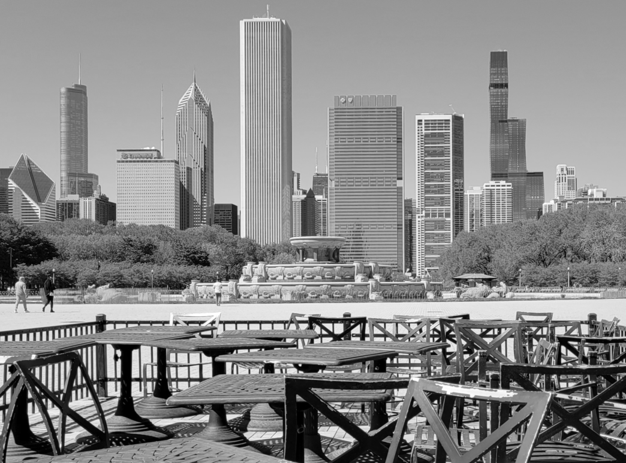

0

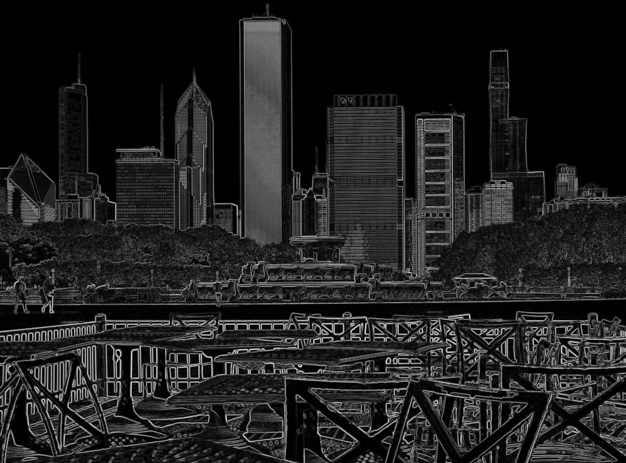

0

In [30]:
# Visualize the output of your function
from IPython.display import display as IPydisplay

with open("images/chicago_skyline_shrunk_v2.bmp", 'rb') as skyline_image_file:
  img_skyline_orig = Image.open(skyline_image_file)
  img_skyline_mat = np.asarray(img_skyline_orig)
  kernel_ver = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
  kernel_hor = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]).T
  img_processed_mat_ver = convolution2d(img_skyline_mat, kernel_ver)
  img_processed_mat_hor = convolution2d(img_skyline_mat, kernel_hor)
  img_processed_mat = np.sqrt(np.multiply(img_processed_mat_ver,
                                          img_processed_mat_ver) + \
                              np.multiply(img_processed_mat_hor,
                                          img_processed_mat_hor))

  img_processed_mat *= 255.0/img_processed_mat.max()
  img_processed_mat = img_processed_mat.astype(np.uint8)
  img_processed = Image.fromarray(img_processed_mat, 'L')
  width, height = img_skyline_orig.size
  scale = 0.6
  IPydisplay(img_skyline_orig.resize((int(width*scale), int(height*scale))),
             Image.NEAREST)
  IPydisplay(img_processed.resize((int(width*scale), int(height*scale))),
             Image.NEAREST)

# Demostración de una CNN en PyTorch

En este punto, deberías tener una idea clara de cómo realizar una convolución sobre una imagen dado un kernel. En la siguiente celda, se proporciona un fragmento de código que demuestra cómo configurar una red convolucional usando PyTorch.

Nos enfocamos en el módulo `nn` de PyTorch. El módulo `nn` contiene una gran cantidad de funciones que facilitan la implementación de una red neuronal. En particular, revisaremos la función `nn.Conv2d()`, que crea una capa convolucional que se aplica a cualquier imagen que se le proporcione a la red resultante.

Observa el siguiente código. En él, definimos una clase `Net` que puedes instanciar con un kernel para crear un objeto de Red Neuronal. Cuando aplicas este objeto de red a una imagen (o a cualquier cosa en forma de matriz), este realiza la convolución del kernel sobre dicha imagen.

In [31]:
class Net(nn.Module):
  """
  A convolutional neural network class.
  When an instance of it is constructed with a kernel, you can apply that instance
    to a matrix and it will convolve the kernel over that image.
  i.e. Net(kernel)(image)
  """

  def __init__(self, kernel=None, padding=0):
    super(Net, self).__init__()
    """
    Summary of the nn.conv2d parameters (you can also get this by hovering
    over the method):
    - in_channels (int): Number of channels in the input image
    - out_channels (int): Number of channels produced by the convolution
    - kernel_size (int or tuple): Size of the convolving kernel

    Args:
      padding: int or tuple, optional
        Zero-padding added to both sides of the input. Default: 0
      kernel: np.ndarray
        Convolving kernel. Default: None

    Returns:
      Nothing
    """
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2,
                           padding=padding)

    # Configura un kernel por defecto si no se provee uno
    if kernel is not None:
      dim1, dim2 = kernel.shape[0], kernel.shape[1]
      kernel = kernel.reshape(1, 1, dim1, dim2)

      self.conv1.weight = torch.nn.Parameter(kernel)
      self.conv1.bias = torch.nn.Parameter(torch.zeros_like(self.conv1.bias))

  def forward(self, x):
    """
    Forward Pass of nn.conv2d

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Convolution output
    """
    x = self.conv1(x)
    return x

In [32]:
# Format a default 2x2 kernel of numbers from 0 through 3
kernel = torch.Tensor(np.arange(4).reshape(2, 2))

# Prepare the network with that default kernel
net = Net(kernel=kernel, padding=0).to(DEVICE)

# Set up a 3x3 image matrix of numbers from 0 through 8
image = torch.Tensor(np.arange(9).reshape(3, 3))
image = image.reshape(1, 1, 3, 3).to(DEVICE)  # BatchSize X Channels X Height X Width

print("Image:\n" + str(image))
print("Kernel:\n" + str(kernel))
output = net(image)  # Apply the convolution
print("Output:\n" + str(output))

Image:
tensor([[[[0., 1., 2.],
          [3., 4., 5.],
          [6., 7., 8.]]]], device='cuda:0')
Kernel:
tensor([[0., 1.],
        [2., 3.]])
Output:
tensor([[[[19., 25.],
          [37., 43.]]]], device='cuda:0', grad_fn=<ConvolutionBackward0>)


Como una nota rápida, observa la diferencia en el tamaño de entrada y salida. La entrada tenía un tamaño de $3 \times 3$, y la salida es de tamaño $2 \times 2$. Esto se debe a que el kernel no puede producir valores para los bordes de la imagen: cuando se desliza hasta un extremo de la imagen y se centra en un píxel del borde, se superpone con un espacio fuera de la imagen que está indefinido.

Si no queremos perder esa información, tendremos que rellenar (pad) la imagen con algunos valores por defecto (como ceros) en el borde. Este proceso se llama, de manera bastante predecible, **padding**. Hablaremos más sobre padding en la siguiente sección.


In [33]:
print("Image (before padding):\n" + str(image))
print("Kernel:\n" + str(kernel))

# Prepara la red con el kernel predeterminado mencionado anteriormente, pero esta vez con padding.
net = Net(kernel=kernel, padding=1).to(DEVICE)
output = net(image)  # Aplica la convolución sobre la imagen con padding.
print("Output:\n" + str(output))

Image (before padding):
tensor([[[[0., 1., 2.],
          [3., 4., 5.],
          [6., 7., 8.]]]], device='cuda:0')
Kernel:
tensor([[0., 1.],
        [2., 3.]])
Output:
tensor([[[[ 0.,  3.,  8.,  4.],
          [ 9., 19., 25., 10.],
          [21., 37., 43., 16.],
          [ 6.,  7.,  8.,  0.]]]], device='cuda:0',
       grad_fn=<ConvolutionBackward0>)


# Kernels, Pooling y Subsampling

Para visualizar los distintos componentes de una CNN, construiremos una CNN simple paso a paso. Recuerda que el conjunto de datos MNIST consiste en imágenes binarizadas de dígitos escritos a mano. Esta vez, usaremos el conjunto de datos EMNIST letters, que consiste en imágenes binarizadas de caracteres escritos a mano  $(A, ..., Z)$.

Simplificaremos aún más el problema quedándonos únicamente con las imágenes que corresponden a la letra $X$ (etiquetada como `24` en el conjunto de datos) y a la letra $O$ (etiquetada como `15` en el conjunto de datos). Luego, entrenaremos una CNN para clasificar una imagen como una $X$ o una $O$.

In [34]:
# @title Bajar EMNIST dataset

# webpage: https://www.itl.nist.gov/iaui/vip/cs_links/EMNIST/gzip.zip
fname = 'EMNIST.zip'
folder = 'EMNIST'
url = "https://osf.io/xwfaj/download"
download_data(fname, folder, url, tar=False)




Extracting the files...



In [35]:
# @title Funciones Dataset/DataLoader  *(Ejecútame)*

def get_Xvs0_dataset(normalize=False, download=False):
  """
  Load Dataset

  Args:
    normalize: boolean
      If true, normalise dataloader
    download: boolean
      If true, download dataset

  Returns:
    emnist_train: torch.loader
      Training Data
    emnist_test: torch.loader
      Test Data
  """
  if normalize:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
  else:
    transform = transforms.Compose([
        transforms.ToTensor(),
        ])

  emnist_train = datasets.EMNIST(root='.',
                                 split='letters',
                                 download=download,
                                 train=True,
                                 transform=transform)
  emnist_test = datasets.EMNIST(root='.',
                                split='letters',
                                download=download,
                                train=False,
                                transform=transform)

  # Only want O (15) and X (24) labels
  train_idx = (emnist_train.targets == 15) | (emnist_train.targets == 24)
  emnist_train.targets = emnist_train.targets[train_idx]
  emnist_train.data = emnist_train.data[train_idx]

  # Convert Xs predictions to 1, Os predictions to 0
  emnist_train.targets = (emnist_train.targets == 24).type(torch.int64)

  test_idx = (emnist_test.targets == 15) | (emnist_test.targets == 24)
  emnist_test.targets = emnist_test.targets[test_idx]
  emnist_test.data = emnist_test.data[test_idx]

  # Convert Xs predictions to 1, Os predictions to 0
  emnist_test.targets = (emnist_test.targets == 24).type(torch.int64)

  return emnist_train, emnist_test


def get_data_loaders(train_dataset, test_dataset,
                     batch_size=32, seed=0):
  """
  Helper function to fetch dataloaders

  Args:
    train_dataset: torch.tensor
      Training data
    test_dataset: torch.tensor
      Test data
    batch_size: int
      Batch Size
    seed: int
      Set seed for reproducibility

  Returns:
    emnist_train: torch.loader
      Training Data
    emnist_test: torch.loader
      Test Data
  """
  g_seed = torch.Generator()
  g_seed.manual_seed(seed)

  train_loader = DataLoader(train_dataset,
                            batch_size=batch_size,
                            shuffle=True,
                            num_workers=2,
                            worker_init_fn=seed_worker,
                            generator=g_seed)
  test_loader = DataLoader(test_dataset,
                           batch_size=batch_size,
                           shuffle=True,
                           num_workers=2,
                           worker_init_fn=seed_worker,
                           generator=g_seed)

  return train_loader, test_loader

In [36]:
emnist_train, emnist_test = get_Xvs0_dataset(normalize=False, download=False)
train_loader, test_loader = get_data_loaders(emnist_train, emnist_test,
                                             seed=SEED)

# Índice de una imagen en el dataset que corresponde a un X u O
x_img_idx = 4
o_img_idx = 15

Revisamos algunos ejemplos del dataset

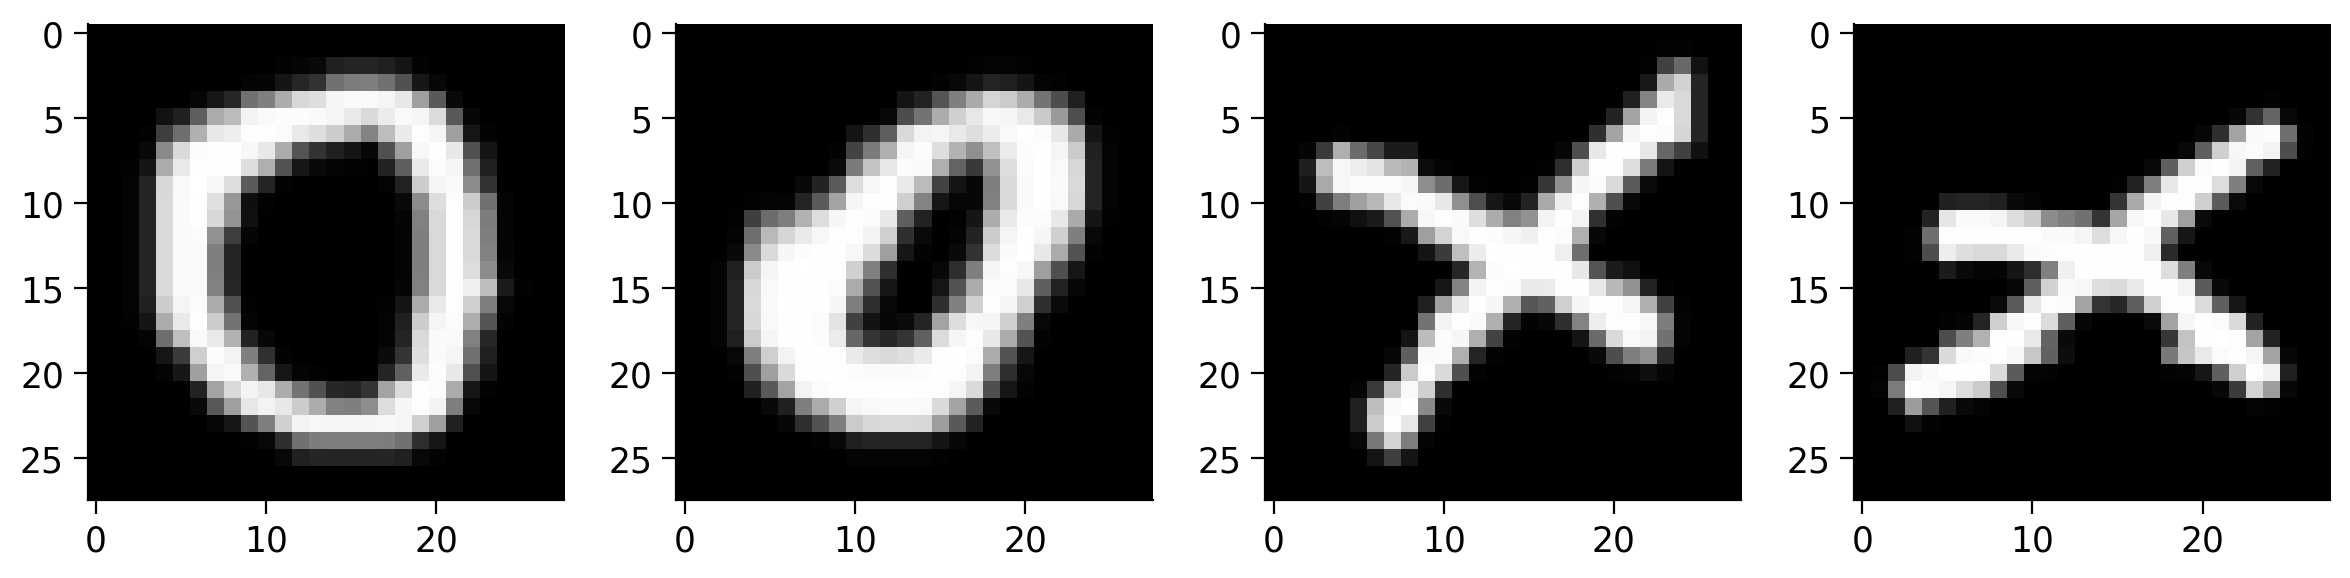

In [37]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 6))
ax1.imshow(emnist_train[0][0].reshape(28, 28), cmap='gray')
ax2.imshow(emnist_train[10][0].reshape(28, 28), cmap='gray')
ax3.imshow(emnist_train[4][0].reshape(28, 28), cmap='gray')
ax4.imshow(emnist_train[6][0].reshape(28, 28), cmap='gray')
plt.show()

#Demostración Interactiva 2: Visualización de la Convolución con Múltiples Filtros

Cambia el número de canales de entrada (por ejemplo, los canales de color de una imagen o los canales de salida de una capa previa) y los canales de salida (número de filtros diferentes a aplicar).

In [38]:
# @markdown *Ejecuta esta celda para habilitar el widget!*

from IPython.display import HTML

id_html = 3
url = f'https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D2_ConvnetsAndDlThinking/static/interactive_demo{id_html}.html'
run_demo = True # @param {type:"boolean"}
if run_demo:
  display(HTML(url))

# Múltiples Filtros

La siguiente red configura 3 filtros y los aplica sobre una imagen del conjunto de datos de la clase $X$. Ten en cuenta que estamos utilizando filtros más “gruesos” que los presentados en los videos. Aquí, los filtros son de $5 \times 5$, mientras que en los videos eran de $3 \times 3$.

In [39]:
class Net2(nn.Module):
  """
  Neural Network instance
  """

  def __init__(self, padding=0):
    """
    Initialize parameters of Net2

    Args:
      padding: int or tuple, optional
        Zero-padding added to both sides of the input. Default: 0

    Returns:
      Nothing
    """
    super(Net2, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=5,
                           padding=padding)

    # First kernel - leading diagonal
    kernel_1 = torch.Tensor([[[1., 1., -1., -1., -1.],
                              [1., 1., 1., -1., -1.],
                              [-1., 1., 1., 1., -1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., -1., -1., 1., 1.]]])

    # Second kernel - other diagonal
    kernel_2 = torch.Tensor([[[-1., -1., -1., 1., 1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., -1., -1.],
                              [1., 1., -1., -1., -1.]]])

    # tThird kernel - checkerboard pattern
    kernel_3 = torch.Tensor([[[1., 1., -1., 1., 1.],
                              [1., 1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., 1., 1.],
                              [1., 1., -1., 1., 1.]]])


    # Stack all kernels in one tensor with (3, 1, 5, 5) dimensions
    multiple_kernels = torch.stack([kernel_1, kernel_2, kernel_3], dim=0)

    self.conv1.weight = torch.nn.Parameter(multiple_kernels)

    # Negative bias
    self.conv1.bias = torch.nn.Parameter(torch.Tensor([-4, -4, -12]))

  def forward(self, x):
    """
    Forward Pass of Net2

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Convolution output
    """
    x = self.conv1(x)
    return x

Nota: Agregamos un sesgo negativo para establecer un umbral que permita seleccionar el valor de salida alto, el cual corresponde a las características que queremos detectar (por ejemplo, una barra orientada a 45 grados).

Ahora, visualicemos los filtros usando el código que se muestra a continuación.

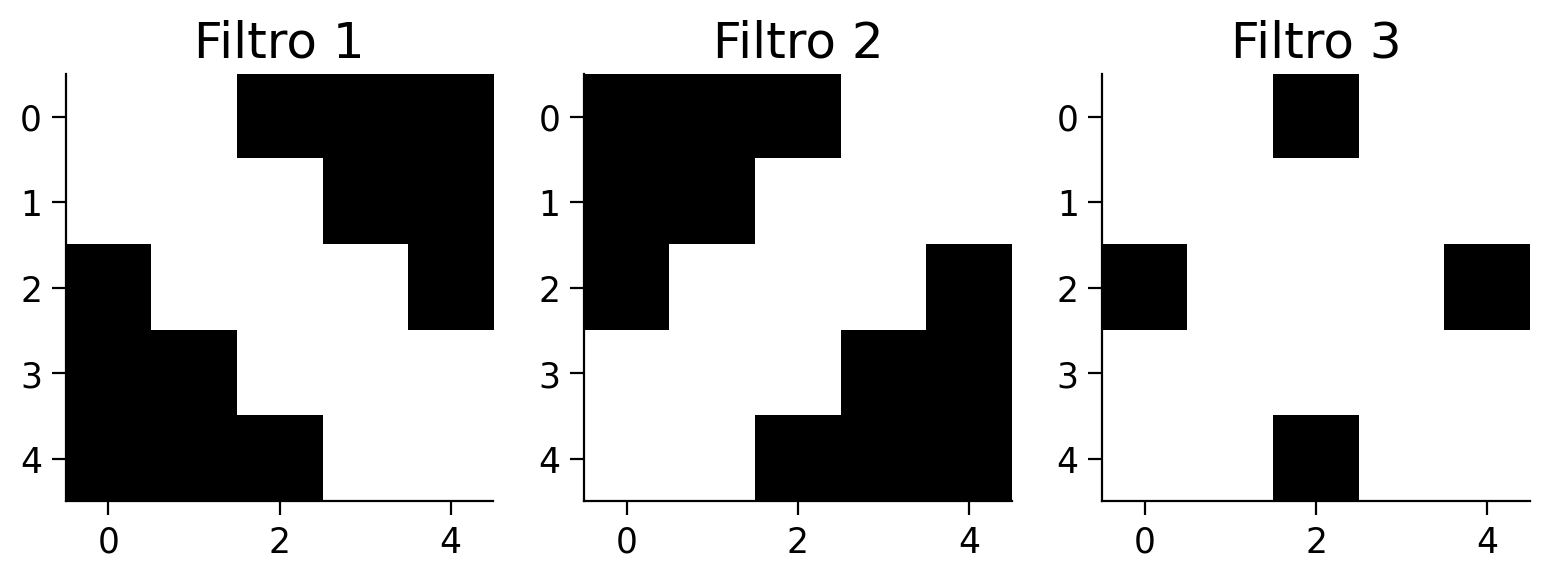

In [40]:
net2 = Net2().to(DEVICE)
fig, (ax11, ax12, ax13) = plt.subplots(1, 3)
# Show the filters
ax11.set_title("Filtro 1")
ax11.imshow(net2.conv1.weight[0, 0].detach().cpu().numpy(), cmap="gray")
ax12.set_title("Filtro 2")
ax12.imshow(net2.conv1.weight[1, 0].detach().cpu().numpy(), cmap="gray")
ax13.set_title("Filtro 3")
ax13.imshow(net2.conv1.weight[2, 0].detach().cpu().numpy(), cmap="gray")

### Reflexión: ¿Ves cómo estos filtros podrían ayudar a reconocer una X?

In [41]:

"""
Estos filtros están diseñados para tener respuestas fuertes a las características de una X
y respuestas más débiles a las características de una O. Los filtros de bordes diagonales
resaltan las diagonales de la X y el patrón en forma de tablero reacciona fuertemente en el
centro de la X, mientras que los bordes más redondeados de la O evocan respuestas más débiles.

Así, las imágenes que tienen diagonales pronunciadas hacia abajo (filtro 1) y hacia arriba
(filtro 3), así como una intersección de ambas (filtro 2), probablemente correspondan a una X.
""";

Aplicamos los filtros a las imágenes

In [42]:
net2 = Net2().to(DEVICE)
x_img = emnist_train[x_img_idx][0].unsqueeze(dim=0).to(DEVICE)
output_x = net2(x_img)
output_x = output_x.squeeze(dim=0).detach().cpu().numpy()

o_img = emnist_train[o_img_idx][0].unsqueeze(dim=0).to(DEVICE)
output_o = net2(o_img)
output_o = output_o.squeeze(dim=0).detach().cpu().numpy()

Veamos la imagen de $X$ y $O$ y cómo se ven los resultados de los filtros aplicados a ellas. Presta especial atención a las áreas con patrones de salida muy altos frente a aquellas con patrones de salida muy bajos.

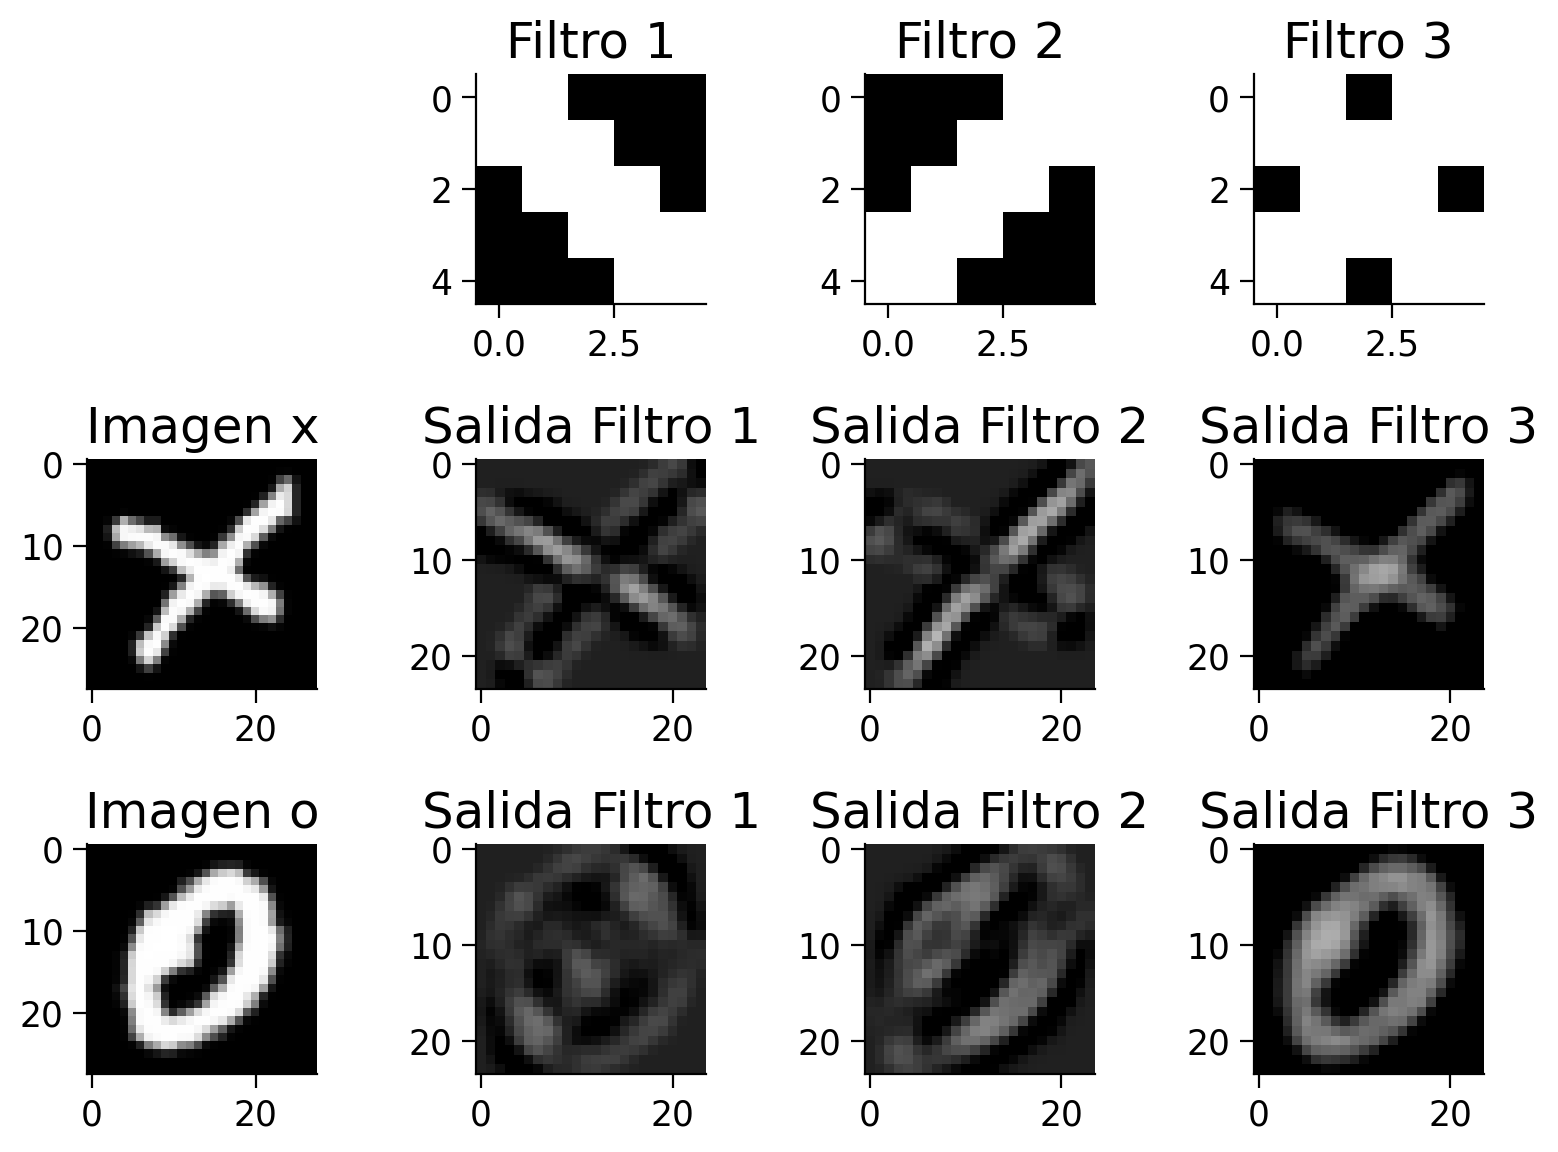

In [43]:
fig, ((ax11, ax12, ax13, ax14),
      (ax21, ax22, ax23, ax24),
      (ax31, ax32, ax33, ax34)) = plt.subplots(3, 4)

# Show the filters
ax11.axis("off")
ax12.set_title("Filtro 1")
ax12.imshow(net2.conv1.weight[0, 0].detach().cpu().numpy(), cmap="gray")
ax13.set_title("Filtro 2")
ax13.imshow(net2.conv1.weight[1, 0].detach().cpu().numpy(), cmap="gray")
ax14.set_title("Filtro 3")
ax14.imshow(net2.conv1.weight[2, 0].detach().cpu().numpy(), cmap="gray")

vmin, vmax = -6, 10
# Show x and the filters applied to x
ax21.set_title("Imagen x")
ax21.imshow(emnist_train[x_img_idx][0].reshape(28, 28), cmap='gray')
ax22.set_title("Salida Filtro 1")
ax22.imshow(output_x[0], cmap='gray', vmin=vmin, vmax=vmax)
ax23.set_title("Salida Filtro 2")
ax23.imshow(output_x[1], cmap='gray', vmin=vmin, vmax=vmax)
ax24.set_title("Salida Filtro 3")
ax24.imshow(output_x[2], cmap='gray', vmin=vmin, vmax=vmax)

# Show o and the filters applied to o
ax31.set_title("Imagen o")
ax31.imshow(emnist_train[o_img_idx][0].reshape(28, 28), cmap='gray')
ax32.set_title("Salida Filtro 1")
ax32.imshow(output_o[0], cmap='gray', vmin=vmin, vmax=vmax)
ax33.set_title("Salida Filtro 2")
ax33.imshow(output_o[1], cmap='gray', vmin=vmin, vmax=vmax)
ax34.set_title("Salida Filtro 3")
ax34.imshow(output_o[2], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

# ReLU después de las convoluciones

Hasta ahora hemos hablado de la operación de convolución, la cual es lineal. Pero la verdadera fortaleza de las redes neuronales proviene de la incorporación de funciones no lineales. Además, en el mundo real, a menudo tenemos problemas de aprendizaje donde la relación entre la entrada y la salida es no lineal y compleja.

La ReLU (Unidad Lineal Rectificada) introduce no linealidad en nuestro modelo, lo que nos permite aprender una función más compleja que pueda predecir mejor la clase de una imagen.

La función ReLU se muestra a continuación.

<br>

<figure>
  <center><img src=https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D2_ConvnetsAndDlThinking/static/relu.png width=400px>
  <figcaption>The Rectified Linear Unit (ReLU) Activation Function<figcaption>
  </center>
</figure>

Ahora incorporemos ReLU en nuestro modelo anterior y visualicemos la salida.

In [44]:
class Net3(nn.Module):
  """
  Neural Network Instance
  """

  def __init__(self, padding=0):
    """
    Initialize Net3 parameters

    Args:
      padding: int or tuple, optional
        Zero-padding added to both sides of the input. Default: 0

    Returns:
      Nothing
    """
    super(Net3, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=5,
                           padding=padding)

    # First kernel - leading diagonal
    kernel_1 = torch.Tensor([[[1., 1., -1., -1., -1.],
                              [1., 1., 1., -1., -1.],
                              [-1., 1., 1., 1., -1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., -1., -1., 1., 1.]]])

    # Second kernel - other diagonal
    kernel_2 = torch.Tensor([[[-1., -1., -1., 1., 1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., -1., -1.],
                              [1., 1., -1., -1., -1.]]])

    # Third kernel -checkerboard pattern
    kernel_3 = torch.Tensor([[[1., 1., -1., 1., 1.],
                              [1., 1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., 1., 1.],
                              [1., 1., -1., 1., 1.]]])


    # Stack all kernels in one tensor with (3, 1, 5, 5) dimensions
    multiple_kernels = torch.stack([kernel_1, kernel_2, kernel_3], dim=0)

    self.conv1.weight = torch.nn.Parameter(multiple_kernels)

    # Negative bias
    self.conv1.bias = torch.nn.Parameter(torch.Tensor([-4, -4, -12]))

  def forward(self, x):
    """
    Forward Pass of Net3

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Convolution output
    """
    x = self.conv1(x)
    x = F.relu(x)
    return x

Aplicamos los filtros y las funciones ReLU a las imágenes.

In [45]:
net3 = Net3().to(DEVICE)
x_img = emnist_train[x_img_idx][0].unsqueeze(dim=0).to(DEVICE)
output_x_relu = net3(x_img)
output_x_relu = output_x_relu.squeeze(dim=0).detach().cpu().numpy()

o_img = emnist_train[o_img_idx][0].unsqueeze(dim=0).to(DEVICE)
output_o_relu = net3(o_img)
output_o_relu = output_o_relu.squeeze(dim=0).detach().cpu().numpy()

Veamos la imagen de $X$ y $O$ y cómo se ven los resultados de los filtros aplicados a ellas.

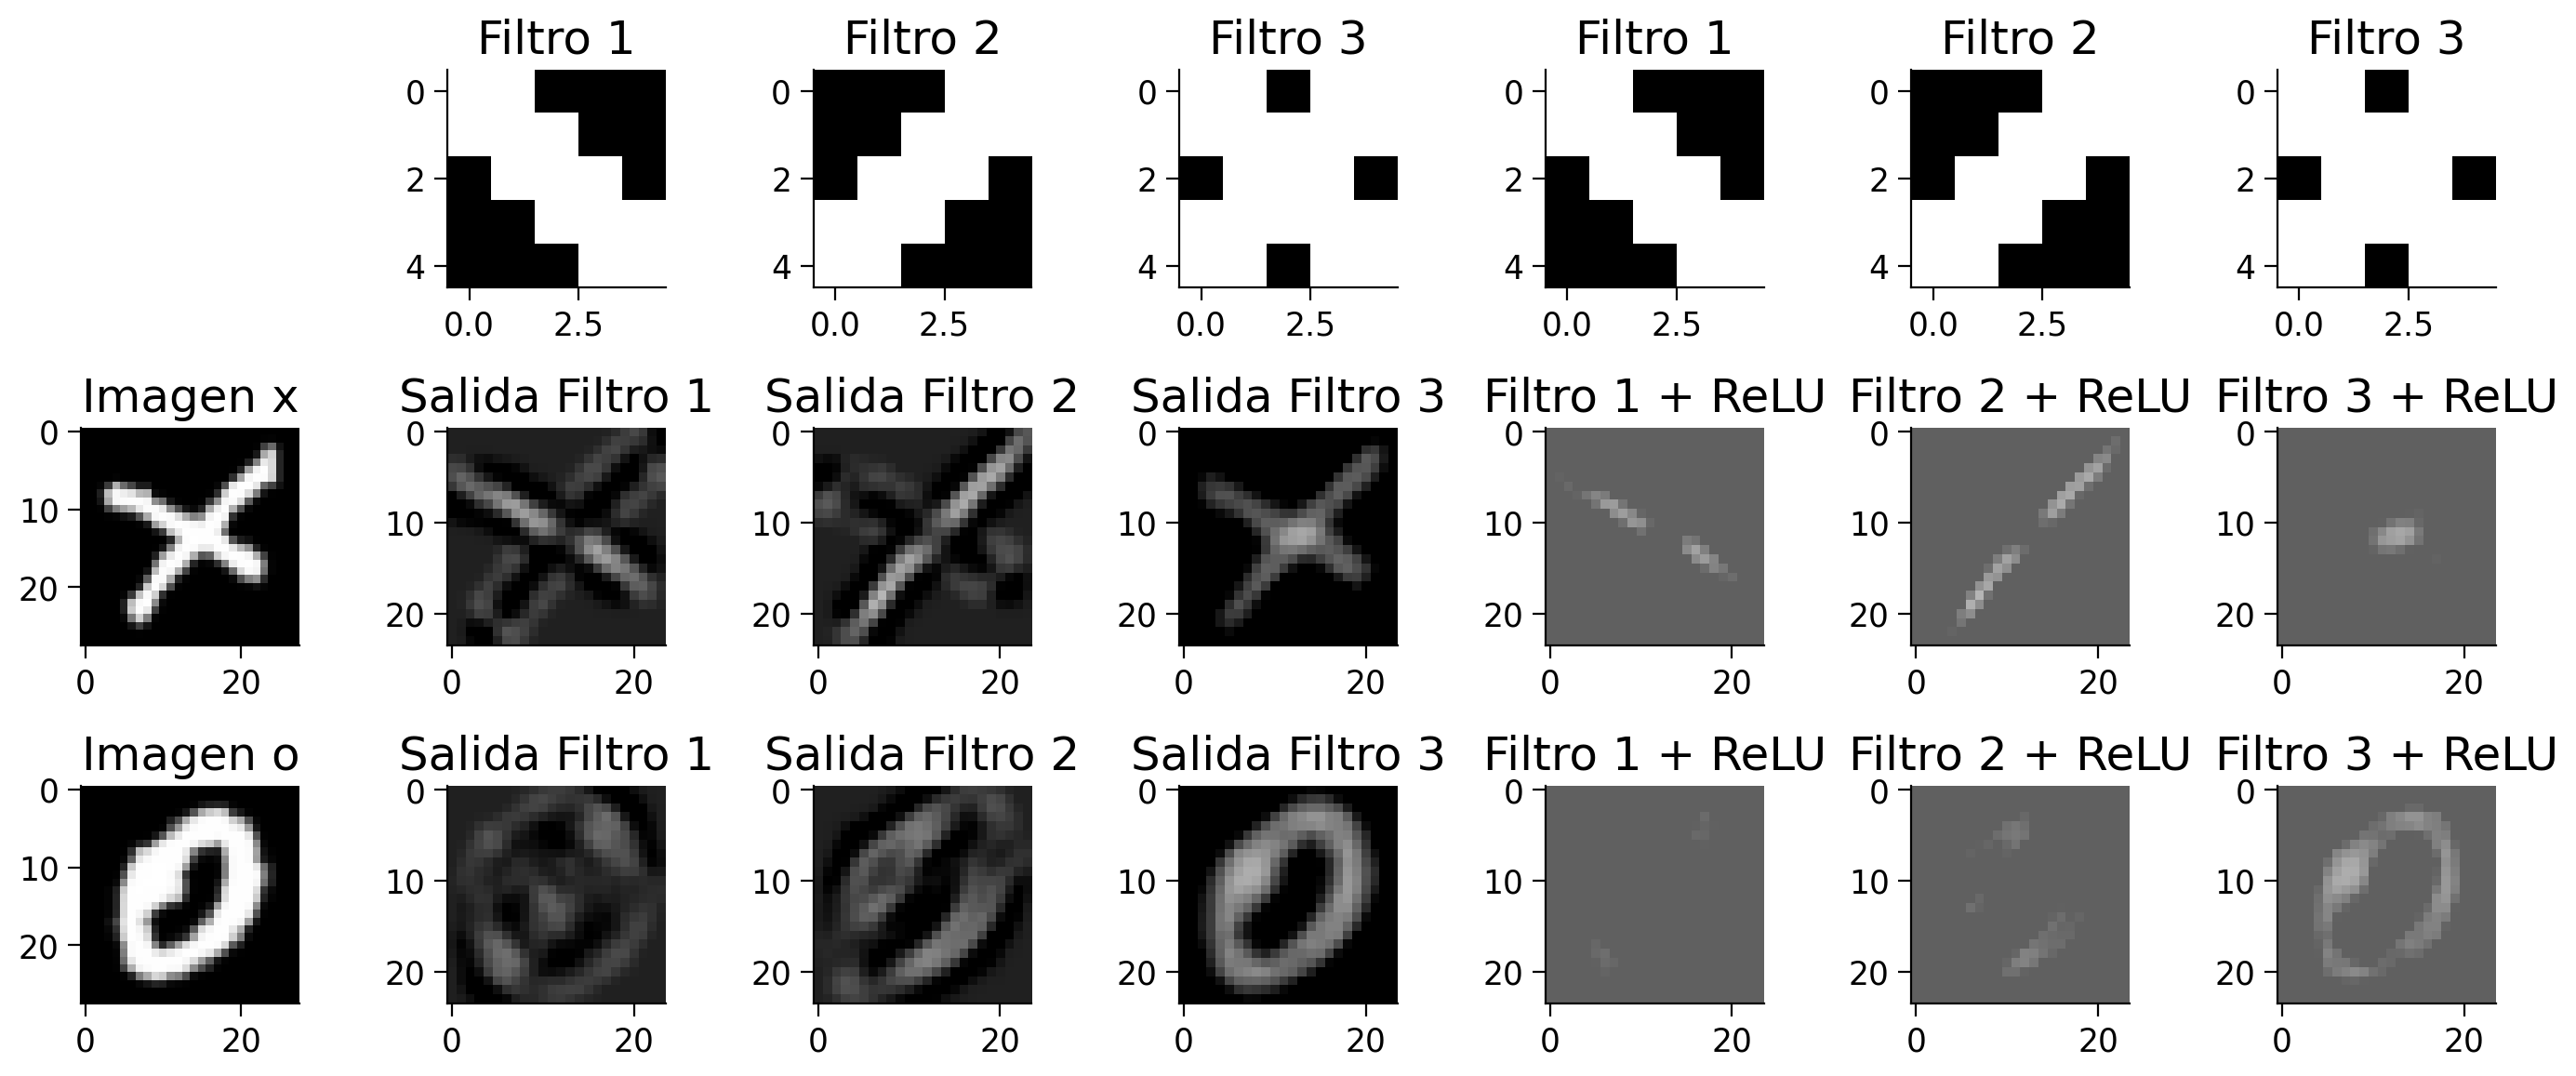

In [46]:
# @markdown *Ejecuta esta celda para ver las imágenes filtradas*
fig, ((ax11, ax12, ax13, ax14, ax15, ax16, ax17),
      (ax21, ax22, ax23, ax24, ax25, ax26, ax27),
      (ax31, ax32, ax33, ax34, ax35, ax36, ax37)) = plt.subplots(3, 4 + 3,
                                                                 figsize=(14, 6))
# Show the filters
ax11.axis("off")
ax12.set_title("Filtro 1")
ax12.imshow(net3.conv1.weight[0, 0].detach().cpu().numpy(), cmap="gray")
ax13.set_title("Filtro 2")
ax13.imshow(net3.conv1.weight[1, 0].detach().cpu().numpy(), cmap="gray")
ax14.set_title("Filtro 3")
ax14.imshow(net3.conv1.weight[2, 0].detach().cpu().numpy(), cmap="gray")

ax15.set_title("Filtro 1")
ax15.imshow(net3.conv1.weight[0, 0].detach().cpu().numpy(), cmap="gray")
ax16.set_title("Filtro 2")
ax16.imshow(net3.conv1.weight[1, 0].detach().cpu().numpy(), cmap="gray")
ax17.set_title("Filtro 3")
ax17.imshow(net3.conv1.weight[2, 0].detach().cpu().numpy(), cmap="gray")

vmin, vmax = -6, 10
# Show x and the filters applied to `x`
ax21.set_title("Imagen x")
ax21.imshow(emnist_train[x_img_idx][0].reshape(28, 28), cmap='gray')
ax22.set_title("Salida Filtro 1")
ax22.imshow(output_x[0], cmap='gray', vmin=vmin, vmax=vmax)
ax23.set_title("Salida Filtro 2")
ax23.imshow(output_x[1], cmap='gray', vmin=vmin, vmax=vmax)
ax24.set_title("Salida Filtro 3")
ax24.imshow(output_x[2], cmap='gray', vmin=vmin, vmax=vmax)

ax25.set_title("Filtro 1 + ReLU")
ax25.imshow(output_x_relu[0], cmap='gray', vmin=vmin, vmax=vmax)
ax26.set_title("Filtro 2 + ReLU")
ax26.imshow(output_x_relu[1], cmap='gray', vmin=vmin, vmax=vmax)
ax27.set_title("Filtro 3 + ReLU")
ax27.imshow(output_x_relu[2], cmap='gray', vmin=vmin, vmax=vmax)

# Show o and the filters applied to `o`
ax31.set_title("Imagen o")
ax31.imshow(emnist_train[o_img_idx][0].reshape(28, 28), cmap='gray')
ax32.set_title("Salida Filtro 1")
ax32.imshow(output_o[0], cmap='gray', vmin=vmin, vmax=vmax)
ax33.set_title("Salida Filtro 2")
ax33.imshow(output_o[1], cmap='gray', vmin=vmin, vmax=vmax)
ax34.set_title("Salida Filtro 3")
ax34.imshow(output_o[2], cmap='gray', vmin=vmin, vmax=vmax)

ax35.set_title("Filtro 1 + ReLU")
ax35.imshow(output_o_relu[0], cmap='gray', vmin=vmin, vmax=vmax)
ax36.set_title("Filtro 2 + ReLU")
ax36.imshow(output_o_relu[1], cmap='gray', vmin=vmin, vmax=vmax)
ax37.set_title("Filtro 3 + ReLU")
ax37.imshow(output_o_relu[2], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

Discute con tu grupo cómo las activaciones ReLU ayudan a reforzar las características necesarias para detectar una \(X\).

<br>

[Aquí](https://stats.stackexchange.com/a/226927) puedes encontrar una discusión que explica cómo ReLU es útil como función de activación.  

[Aquí](https://stats.stackexchange.com/questions/126238/what-are-the-advantages-of-relu-over-sigmoid-function-in-deep-neural-networks?sfb=2) puedes encontrar otra excelente discusión sobre las ventajas de usar ReLU.


# Pooling

Las capas convolucionales crean mapas de características que resumen la presencia de determinadas características (por ejemplo, bordes) en la entrada. Sin embargo, estos mapas de características registran la posición _precisa_ de las características en la entrada. Eso significa que pequeños cambios en la posición de un objeto en una imagen pueden dar como resultado un mapa de características muy diferente. ¡Pero una taza es una taza (y una \(X\) es una \(X\)) sin importar dónde aparezca en la imagen! Necesitamos lograr la _invarianza traslacional_.  

Un enfoque común para este problema se llama **downsampling** (submuestreo). El downsampling crea una versión de menor resolución de una imagen, conservando los elementos estructurales grandes y eliminando algunos de los detalles finos que pueden ser menos relevantes para la tarea. En las CNNs, se utilizan **Max-Pooling** y **Average-Pooling** para realizar el downsampling. Estas operaciones reducen el tamaño de las capas ocultas y producen características que son más invariables a traslaciones, lo cual puede ser mejor aprovechado por las capas posteriores.


Al igual que las capas convolucionales, las capas de pooling tienen ventanas de forma fija (ventanas de pooling) que se aplican sistemáticamente a la entrada. Al igual que con los filtros, podemos cambiar la forma de la ventana y el tamaño del *stride*. Y, al igual que con los filtros, cada vez que aplicamos una operación de pooling producimos una sola salida.  

El pooling realiza una especie de compresión de la información que proporciona estadísticas resumidas para un _vecindario_ de la entrada.  
- En **Maxpooling**, calculamos el valor máximo de todos los píxeles en la ventana de pooling.  
- En **Avgpooling**, calculamos el valor promedio de todos los píxeles en la ventana de pooling.  

El siguiente ejemplo muestra el resultado de **Maxpooling** dentro de las ventanas amarillas de pooling para crear la matriz de salida de pooling en rojo.

<figure>
    <center><img src=https://developers.google.com/machine-learning/glossary/images/PoolingConvolution.svg?hl=fr width=400px>
    <figcaption>An Example of Pooling with a kernel size of 2</figcaption>
    </center>
</figure>

El pooling le da a nuestra red **invarianza traslacional** al proporcionar un resumen de los valores en cada ventana de pooling. De este modo, un pequeño cambio en las características de la imagen subyacente no generará una gran diferencia en la salida.  

Es importante notar que, a diferencia de una capa convolucional, ¡la capa de pooling no contiene parámetros que deban aprenderse! El pooling simplemente calcula un resumen predefinido de la entrada y lo transmite. Esto contrasta con la capa convolucional, donde sí existen filtros que deben aprenderse.


# El Efecto del Stride

La siguiente animación muestra cómo cambiar el *stride* modifica la salida. El *stride* define cuánto se desplaza la región de pooling sobre la matriz de entrada para producir la siguiente salida (flechas rojas en la animación).  

¡Pruébalo! Cambia el *stride* y observa cómo afecta la forma de la salida. También puedes probar **MaxPool** o **AvgPool**.


In [47]:
# @markdown *Run this cell to enable the widget!*

from IPython.display import HTML

id_html = 3.3
url = f'https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D2_ConvnetsAndDlThinking/static/interactive_demo{id_html}.html'
run_demo = True # @param {type:"boolean"}
if run_demo:
  display(HTML(url))

# Ejercicio: Implementar Max Pooling

Ahora implementemos **MaxPooling** en PyTorch y observemos los efectos del *Pooling* en la dimensión de la imagen de entrada. Utiliza un kernel de tamaño 2 y un *stride* de 2 para la capa de MaxPooling.


```python
class Net4(nn.Module):
  """
  Neural Network instance
  """

  def __init__(self, padding=0, stride=2):
    """
    Initialise parameters of Net4

    Args:
      padding: int or tuple, optional
        Zero-padding added to both sides of the input. Default: 0
      stride: int
        Stride

    Returns:
      Nothing
    """
    super(Net4, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=5,
                            padding=padding)

    # First kernel - leading diagonal
    kernel_1 = torch.Tensor([[[1., 1., -1., -1., -1.],
                              [1., 1., 1., -1., -1.],
                              [-1., 1., 1., 1., -1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., -1., -1., 1., 1.]]])

    # Second kernel - other diagonal
    kernel_2 = torch.Tensor([[[-1., -1., -1., 1., 1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., -1., -1.],
                              [1., 1., -1., -1., -1.]]])

    # Third kernel -checkerboard pattern
    kernel_3 = torch.Tensor([[[1., 1., -1., 1., 1.],
                              [1., 1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., 1., 1.],
                              [1., 1., -1., 1., 1.]]])


    # Stack all kernels in one tensor with (3, 1, 5, 5) dimensions
    multiple_kernels = torch.stack([kernel_1, kernel_2, kernel_3], dim=0)

    self.conv1.weight = torch.nn.Parameter(multiple_kernels)

    # Negative bias
    self.conv1.bias = torch.nn.Parameter(torch.Tensor([-4, -4, -12]))
    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    raise NotImplementedError("Define el maxpool layer")
    ####################################################################
    self.pool = nn.MaxPool2d(kernel_size=..., stride=...)

  def forward(self, x):
    """
    Forward Pass of Net4

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Convolution + ReLU output
    """
    x = self.conv1(x)
    x = F.relu(x)
    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    raise NotImplementedError("Define el maxpool layer")
    ####################################################################
    x = ...  # Pasa a través de un max pool layer
    return x



## Evalúa si tu implementación es correcta
# net4 = Net4().to(DEVICE) # Descomenta esta línea y ejecútala
# check_pooling_net(net4, device=DEVICE) # Descomenta esta línea y ejecútala

```

In [48]:
# Aquí deja tu código con tu implementación

class Net4(nn.Module):
  """
  Neural Network instance
  """

  def __init__(self, padding=0, stride=2):
    """
    Initialise parameters of Net4

    Args:
      padding: int or tuple, optional
        Zero-padding added to both sides of the input. Default: 0
      stride: int
        Stride

    Returns:
      Nothing
    """
    super(Net4, self).__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=5,
                            padding=padding)

    # First kernel - leading diagonal
    kernel_1 = torch.Tensor([[[1., 1., -1., -1., -1.],
                              [1., 1., 1., -1., -1.],
                              [-1., 1., 1., 1., -1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., -1., -1., 1., 1.]]])

    # Second kernel - other diagonal
    kernel_2 = torch.Tensor([[[-1., -1., -1., 1., 1.],
                              [-1., -1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., -1., -1.],
                              [1., 1., -1., -1., -1.]]])

    # Third kernel -checkerboard pattern
    kernel_3 = torch.Tensor([[[1., 1., -1., 1., 1.],
                              [1., 1., 1., 1., 1.],
                              [-1., 1., 1., 1., -1.],
                              [1., 1., 1., 1., 1.],
                              [1., 1., -1., 1., 1.]]])


    # Stack all kernels in one tensor with (3, 1, 5, 5) dimensions
    multiple_kernels = torch.stack([kernel_1, kernel_2, kernel_3], dim=0)

    self.conv1.weight = torch.nn.Parameter(multiple_kernels)

    # Negative bias
    self.conv1.bias = torch.nn.Parameter(torch.Tensor([-4, -4, -12]))
    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    #raise NotImplementedError("Define el maxpool layer")
    ####################################################################
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    """
    Forward Pass of Net4

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Convolution + ReLU output
    """
    x = self.conv1(x)
    x = F.relu(x)
    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    # raise NotImplementedError("Define el maxpool layer")
    ####################################################################
    # Pasa a través de un max pool layer
    x = self.pool(x)
    return x



## Evalúa si tu implementación es correcta
net4 = Net4().to(DEVICE) # Descomenta esta línea y ejecútala
check_pooling_net(net4, device=DEVICE) # Descomenta esta línea y ejecútala

✅ Your network produced the correct output.


In [49]:
x_img = emnist_train[x_img_idx][0].unsqueeze(dim=0).to(DEVICE)
output_x_pool = net4(x_img)
output_x_pool = output_x_pool.squeeze(dim=0).detach().cpu().numpy()

o_img = emnist_train[o_img_idx][0].unsqueeze(dim=0).to(DEVICE)
output_o_pool = net4(o_img)
output_o_pool = output_o_pool.squeeze(dim=0).detach().cpu().numpy()

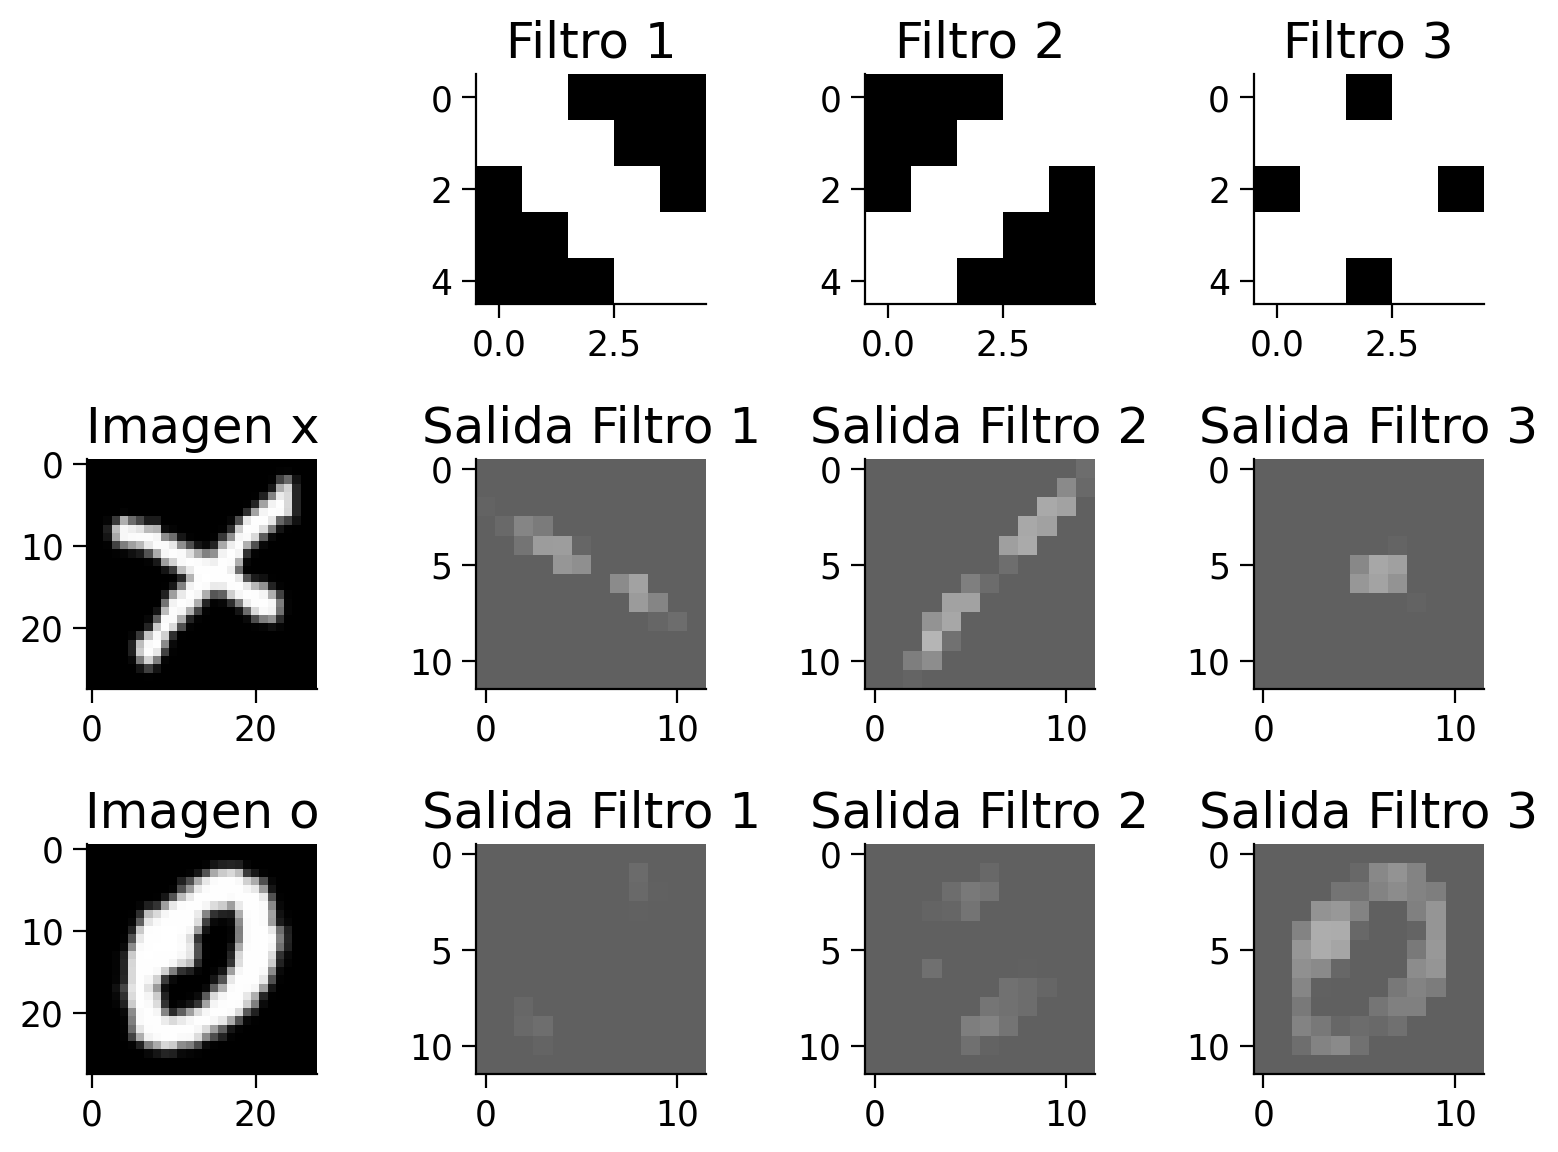

In [50]:
# @markdown *Ejecuta la celda*

fig, ((ax11, ax12, ax13, ax14),
      (ax21, ax22, ax23, ax24),
      (ax31, ax32, ax33, ax34)) = plt.subplots(3, 4)
# Show the filters
ax11.axis("off")
ax12.set_title("Filtro 1")
ax12.imshow(net4.conv1.weight[0, 0].detach().cpu().numpy(), cmap="gray")
ax13.set_title("Filtro 2")
ax13.imshow(net4.conv1.weight[1, 0].detach().cpu().numpy(), cmap="gray")
ax14.set_title("Filtro 3")
ax14.imshow(net4.conv1.weight[2, 0].detach().cpu().numpy(), cmap="gray")

vmin, vmax = -6, 10
# Show x and the filters applied to x
ax21.set_title("Imagen x")
ax21.imshow(emnist_train[x_img_idx][0].reshape(28, 28), cmap='gray')
ax22.set_title("Salida Filtro 1")
ax22.imshow(output_x_pool[0], cmap='gray', vmin=vmin, vmax=vmax)
ax23.set_title("Salida Filtro 2")
ax23.imshow(output_x_pool[1], cmap='gray', vmin=vmin, vmax=vmax)
ax24.set_title("Salida Filtro 3")
ax24.imshow(output_x_pool[2], cmap='gray', vmin=vmin, vmax=vmax)

# Show o and the filters applied to o
ax31.set_title("Imagen o")
ax31.imshow(emnist_train[o_img_idx][0].reshape(28, 28), cmap='gray')
ax32.set_title("Salida Filtro 1")
ax32.imshow(output_o_pool[0], cmap='gray', vmin=vmin, vmax=vmax)
ax33.set_title("Salida Filtro 2")
ax33.imshow(output_o_pool[1], cmap='gray', vmin=vmin, vmax=vmax)
ax34.set_title("Salida Filtro 3")
ax34.imshow(output_o_pool[2], cmap='gray', vmin=vmin, vmax=vmax)
plt.show()

Deberías observar que el tamaño de la salida es la mitad de lo que viste después de la sección de ReLU, lo cual se debe a la capa de MaxPool.  

A pesar de la reducción en el tamaño de la salida, las características importantes o de alto nivel en la salida se mantienen intactas.


# Poniendo todo junto

## Número de parámetros en modelos convolucionales vs. completamente conectados

Las redes convolucionales fomentan el **compartir de pesos** al aprender un único kernel que se repite sobre toda la imagen de entrada. En general, este kernel consiste en solo unos pocos parámetros, en comparación con la enorme cantidad de parámetros en una red densa.  

Usemos la animación a continuación para calcular los parámetros de una red con pocas capas para datos de imagen de forma \(32\times32\), utilizando tanto capas convolucionales como capas densas.  

`Num_Dense` en este ejercicio es el número de capas densas que usamos en la red, donde cada capa densa tiene las mismas dimensiones de entrada y salida.  

`Num_Convs` es el número de bloques convolucionales en la red, con cada bloque conteniendo un único kernel. El tamaño del kernel corresponde a la longitud y anchura de dicho kernel.


<br>
<center>
  <img src=https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W2D2_ConvnetsAndDlThinking/static/img_params.png>
  <figcaption> Parameter comparison</figcaption>
</center>


# Número de parámetros



In [51]:
# @markdown *Ejecuta la celda para habilitar el widget*
import io, base64
from ipywidgets import interact, interactive, fixed, interact_manual


def do_plot(image_size, batch_size, number_of_Linear, number_of_Conv2d,
            kernel_size, pooling, Final_Layer):
  sample_image = torch.rand(batch_size, 1, image_size, image_size)
  linear_layer = []
  linear_nets = []
  code_dense = ""

  code_dense += f"model_dense = nn.Sequential(\n"
  code_dense += f"    nn.Flatten(),\n"
  for i in range(number_of_Linear):
    linear_layer.append(nn.Linear(image_size * image_size * 1,
                                  image_size * image_size * 1,
                                  bias=False))
    linear_nets.append(nn.Sequential(*linear_layer))
    code_dense += f"    nn.Linear({image_size}*{image_size}*1, {image_size}*{image_size}*1, bias=False),\n"
  if Final_Layer is True:
    linear_layer.append(nn.Linear(image_size * image_size * 1, 10,
                                  bias=False))
    linear_nets.append(nn.Sequential(*linear_layer))
    code_dense += f"    nn.Linear({image_size}*{image_size}*1, 10, bias=False)\n"
  code_dense += ")\n"
  code_dense += "result_dense = model_dense(sample_image)\n"
  linear_layer = nn.Sequential(*linear_layer)

  conv_layer = []
  conv_nets = []
  code_conv = ""

  code_conv += f"model_conv = nn.Sequential(\n"
  for i in range(number_of_Conv2d):
    conv_layer.append(nn.Conv2d(in_channels=1,
                                out_channels=1,
                                kernel_size=kernel_size,
                                padding=kernel_size // 2,
                                bias=False))

    conv_nets.append(nn.Sequential(*conv_layer))
    code_conv += f"    nn.Conv2d(in_channels=1, out_channels=1, kernel_size={kernel_size}, padding={kernel_size//2}, bias=False),\n"
    if pooling > 0:
      conv_layer.append(nn.MaxPool2d(2, 2))
      code_conv += f"    nn.MaxPool2d(2, 2),\n"
    conv_nets.append(nn.Sequential(*conv_layer))
  if Final_Layer is True:
    conv_layer.append(nn.Flatten())
    code_conv += f"    nn.Flatten(),\n"
    conv_nets.append(nn.Sequential(*conv_layer))
    shape_conv = conv_nets[-1](sample_image).shape
    conv_layer.append(nn.Linear(shape_conv[1], 10, bias=False))
    code_conv += f"    nn.Linear({shape_conv[1]}, 10, bias=False),\n"
    conv_nets.append(nn.Sequential(*conv_layer))
  conv_layer = nn.Sequential(*conv_layer)
  code_conv += ")\n"
  code_conv += "result_conv = model_conv(sample_image)\n"


  t_1 = time.time()
  shape_linear = linear_layer(torch.flatten(sample_image, 1)).shape
  t_2 = time.time()
  shape_conv = conv_layer(sample_image).shape
  t_3 = time.time()

  print("Time taken by Dense Layer {}".format(t_2 - t_1))
  print("Time taken by Conv Layer  {}".format(t_3 - t_2))

  ax = plt.axes((0, 0, 1, 1))
  ax.spines["left"].set_visible(False)
  plt.yticks([])
  ax.spines["bottom"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.spines["top"].set_visible(False)
  plt.xticks([])
  p1 = sum(p.numel() for p in linear_layer.parameters())
  nl = '\n'
  p2 = sum(p.numel() for p in conv_layer.parameters())
  plt.text(0.1, 0.8,
           f"Total Parameters in Dense Layer {p1:10,d}{nl}Total Parameters in Conv Layer   {p2:10,d}")

  plt.text(0.23, 0.62, "Dense Net", rotation=90,
           color='k', ha="center", va="center")

  def addBox(x, y, w, h, color, text1, text2, text3):
      """
      Function to render widget
      """
      ax.add_patch(plt.Rectangle((x, y), w, h, fill=True, color=color,
                                 alpha=0.5, zorder=1000, clip_on=False))
      plt.text(x + 0.02, y + h / 2, text1, rotation=90,
               va="center", ha="center", size=12)
      plt.text(x + 0.05, y + h / 2, text2, rotation=90,
               va="center", ha="center")
      plt.text(x + 0.08, y + h / 2, text3, rotation=90,
               va="center", ha="center", size=12)

  x = 0.25
  if 1:
    addBox(x, 0.5, 0.08, 0.25, [1, 0.5, 0], "Flatten",
           tuple(torch.flatten(sample_image, 1).shape), "")
    x += 0.08 + 0.01

  for i in range(number_of_Linear):
    addBox(x, 0.5, 0.1, 0.25, "g", "Dense",
           tuple(linear_nets[i](torch.flatten(sample_image, 1)).shape),
           list(linear_layer.parameters())[i].numel())
    x += 0.11

  if Final_Layer is True:
    i = number_of_Linear
    addBox(x, 0.5, 0.1, 0.25, "g", "Dense",
           tuple(linear_nets[i](torch.flatten(sample_image, 1)).shape),
           list(linear_layer.parameters())[i].numel())

  plt.text(0.23, 0.1 + 0.35 / 2, "Conv Net",
           rotation=90, color='k',
           ha="center", va="center")
  x = 0.25

  for i in range(number_of_Conv2d):
    addBox(x, 0.1, 0.1, 0.35, "r", "Conv",
           tuple(conv_nets[i * 2](sample_image).shape),
           list(conv_nets[i * 2].parameters())[-1].numel())
    x += 0.11
    if pooling > 0:
      addBox(x, 0.1, 0.08, 0.35, [0, 0.5, 1], "Pooling",
             tuple(conv_nets[i * 2 + 1](sample_image).shape), "")
      x += 0.08 + 0.01

  if Final_Layer is True:
    i = number_of_Conv2d
    addBox(x, 0.1, 0.08, 0.35, [1, 0.5, 0], "Flatten",
           tuple(conv_nets[i * 2](sample_image).shape), "")
    x += 0.08 + 0.01

    addBox(x, 0.1, 0.1, 0.35, "g", "Dense",
            tuple(conv_nets[i * 2 + 1](sample_image).shape),
            list(conv_nets[i * 2 + 1].parameters())[-1].numel())
    x += 0.11

  plt.text(0.08, 0.3 + 0.35 / 2,
           "Input", rotation=90, color='b', ha="center", va="center")

  ax.add_patch(plt.Rectangle((0.1, 0.3), 0.1, 0.35, fill=True, color='b',
                             alpha=0.5, zorder=1000, clip_on=False))
  plt.text(0.1 + 0.1 / 2, 0.3 + 0.35 / 2, tuple(sample_image.shape),
           rotation=90, va="center", ha="center")

  # Plot
  plt.gcf().set_tight_layout(False)
  my_stringIObytes = io.BytesIO()
  plt.savefig(my_stringIObytes, format='png', dpi=90)
  my_stringIObytes.seek(0)
  my_base64_jpgData = base64.b64encode(my_stringIObytes.read())

  del linear_layer, conv_layer

  plt.close()
  mystring = """<img src="data:image/png;base64,""" + str(my_base64_jpgData)[2:-1] + """" alt="Graph">"""

  return code_dense, code_conv, mystring


# Parameters
caption = widgets.Label(value='The values of range1 and range2 are synchronized')
slider_batch_size = widgets.IntSlider(value=100, min=10, max=100, step=10,
                                      description="BatchSize")
slider_image_size = widgets.IntSlider(value=32, min=32, max=128, step=32,
                                      description="ImageSize")
slider_number_of_Linear = widgets.IntSlider(value=1,min=1, max=3, step=1,
                                            description="NumDense")
slider_number_of_Conv2d = widgets.IntSlider(value=1, min=1, max=2, step=1,
                                            description="NumConv")
slider_kernel_size = widgets.IntSlider(value=5, min=3, max=21, step=2,
                                       description="KernelSize")
input_pooling = widgets.Checkbox(value=False,
                                 description="Pooling")
input_Final_Layer = widgets.Checkbox(value=False,
                                     description="Final_Layer")

output_code1 = widgets.HTML(value="", )

output_plot = widgets.HTML(value="", )


def plot_func(batch_size, image_size,
              number_of_Linear, number_of_Conv2d,
              kernel_size, pooling, Final_Layer):

    code1, code2, plot = do_plot(image_size, batch_size,
                                 number_of_Linear, number_of_Conv2d,
                                 kernel_size, pooling, Final_Layer)
    output_plot.value = plot

    output_code1.value = """
    <!DOCTYPE html>
    <html>
      <head>
        <style>
          * {
            box-sizing: border-box;
          }
          .column {
            float: left;
            /*width: 33.33%;*/
            padding: 5px;
          }
          /* Clearfix (clear floats) */
          .row::after {
            content: "";
            clear: both;
            display: table;
          }
          pre {
            line-height: 1.2em;
          }
        </style>
      </head>

      <body>
        <div class="row">
          <div class="column" style="overflow-x: scroll;">
          <h2>Code for Dense Network</h2>
          <pre>""" + code1 + """</pre>
        </div>
          <div class="column" style="overflow-x: scroll;">
          <h2>Code for Conv Network</h2>
          <pre>""" + code2 + """</pre>
          </div>
        </div>
      </body>
    </html>
"""

out = widgets.interactive_output(plot_func, {
    "batch_size": slider_batch_size,
    "image_size": slider_image_size,
    "number_of_Linear": slider_number_of_Linear,
    "number_of_Conv2d": slider_number_of_Conv2d,
    "kernel_size": slider_kernel_size,
    "pooling": input_pooling,
    "Final_Layer": input_Final_Layer,
})

ui = widgets.VBox([slider_batch_size, slider_image_size,
                   slider_number_of_Linear,
                   widgets.HBox([slider_number_of_Conv2d,
                                 slider_kernel_size,
                                 input_pooling]),
                   input_Final_Layer])
display(widgets.HBox([output_plot, output_code1]), ui)
display(out)

Output()

La diferencia en el número de parámetros es enorme, y continúa aumentando a medida que crece el tamaño de la imagen de entrada. Las imágenes más grandes requieren que la capa lineal use una matriz que pueda multiplicarse directamente con los píxeles de entrada.  

<br>

Si bien el *pooling* no reduce el número de parámetros de una capa convolucional posterior, sí disminuye el tamaño de la imagen. Por lo tanto, las capas densas posteriores necesitarán menos parámetros.  

<br>

El tamaño de los parámetros de una CNN, sin embargo, es invariante al tamaño de la imagen, ya que, independientemente de la entrada que reciba, sigue deslizando el mismo filtro aprendible sobre las imágenes.  

El conjunto reducido de parámetros no solo disminuye enormemente el uso de memoria, sino que también permite que el modelo generalice mejor.


# Implementando tu propia CNN

Apilemos todo lo que hemos aprendido. Crea una CNN con la siguiente estructura. <br>
- Convolución `nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)`
- Convolución `nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)`
- Capa de *Pooling* `nn.MaxPool2d(kernel_size=2)`
- Capa Totalmente Conectada `nn.Linear(in_features=9216, out_features=128)`
- Capa Totalmente Conectada `nn.Linear(in_features=128, out_features=2)`

**Nota:** Como se discutió en el video, queremos aplanar (*flatten*) la salida de las capas convolucionales antes de pasarla a las capas lineales, convirtiendo así una entrada de forma
\([\text{BatchSize}, \text{Channels}, \text{Height}, \text{Width}]\) en
\([\text{BatchSize}, \text{Channels} \times \text{Height} \times \text{Width}]\), lo cual, en este caso, sería de \([32, 64, 12, 12]\) (salida de la segunda capa convolucional) a
\([32, 64 \times 12 \times 12] = [32, 9216]\). Recuerda que las imágenes de entrada tienen tamaño \([28, 28]\).

**Pista:** Puedes usar `torch.flatten(x, 1)` para aplanar la entrada en esta etapa. El `1` indica que se aplanan las dimensiones comenzando desde la dimensión 1, para excluir la dimensión de *batch* del aplanado.

También debemos pensar en cómo obtenemos que la salida de la capa de *pooling* sea de \(12 \times 12\). Esto se debe a que, primero, las dos operaciones `Conv2d` con `kernel_size=3` reducen la imagen a \(26 \times 26\) y la segunda `Conv2d` la reduce a \(24 \times 24\). Finalmente, la operación `MaxPool2d` reduce el tamaño de salida a la mitad, quedando en \(12 \times 12\).

Además, no olvides las ReLU (usa, por ejemplo, `F.ReLU`). No es necesario añadir una ReLU después de la última capa totalmente conectada.


In [52]:
# @title Funciones Train/Test (Ejecutar)

# @markdown Doble click para ver los contenidos!

def train(model, device, train_loader, epochs):
  """
  Training function

  Args:
    model: nn.module
      Neural network instance
    device: string
      GPU/CUDA if available, CPU otherwise
    epochs: int
      Number of epochs
    train_loader: torch.loader
      Training Set

  Returns:
    Nothing
  """
  model.train()

  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
  for epoch in range(epochs):
    with tqdm(train_loader, unit='batch') as tepoch:
      for data, target in tepoch:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        tepoch.set_postfix(loss=loss.item())
        time.sleep(0.1)

def test(model, device, data_loader):
  """
  Test function

  Args:
    model: nn.module
      Neural network instance
    device: string
      GPU/CUDA if available, CPU otherwise
    data_loader: torch.loader
      Test Set

  Returns:
    acc: float
      Test accuracy
  """
  model.eval()
  correct = 0
  total = 0
  for data in data_loader:
    inputs, labels = data
    inputs = inputs.to(device).float()
    labels = labels.to(device).long()

    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  acc = 100 * correct / total
  return acc

Descargamos los datos. Observa que aquí normalizamos el conjunto de datos.


In [53]:
set_seed(SEED)
emnist_train, emnist_test = get_Xvs0_dataset(normalize=True)
train_loader, test_loader = get_data_loaders(emnist_train, emnist_test,
                                             seed=SEED)

Random seed 2021 has been set.


```python
class EMNIST_Net(nn.Module):
  """
  Neural network instance with following structure
  nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3) # Convolutional Layer 1
  nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3) + max-pooling # Convolutional Block 2
  nn.Linear(in_features=9216, out_features=128) # Fully Connected Layer 1
  nn.Linear(in_features=128, out_features=2) # Fully Connected Layer 2
  """

  def __init__(self):
    """
    Initialize parameters of EMNISTNet

    Args:
      None

    Returns:
      Nothing
    """
    super(EMNIST_Net, self).__init__()

    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    raise NotImplementedError("Define las capas solicitadas")
    ####################################################################
    self.conv1 = nn.Conv2d(...)
    self.conv2 = nn.Conv2d(...)
    self.fc1 = nn.Linear(...)
    self.fc2 = nn.Linear(...)
    self.pool = nn.MaxPool2d(...)

  def forward(self, x):
    """
    Forward pass of EMNISTNet

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Output of final fully connected layer
    """
    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    # Pista: No olvides aplanar (*flatten*) la imagen cuando pasa de
    # capas de convolución a capas lineales!
    raise NotImplementedError("Define el forward pass para cualquier input x")
    ####################################################################
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = ...
    x = ...
    x = ...
    x = ...
    x = ...
    x = ...
    return x



## Descomenta las líneas abajo para entrenar tu red
# emnist_net = EMNIST_Net().to(DEVICE)
# print("Número total Parameters in Network {:10d}".format(sum(p.numel() for p in emnist_net.parameters())))
# train(emnist_net, DEVICE, train_loader, 1)
## Uncomment to test your model
# print(f'Test accuracy is: {test(emnist_net, DEVICE, test_loader)}')

```

¡Deberías haber obtenido una exactitud de prueba de alrededor de \(99\%\)!

# Actividad 10
Por favor, desarrolla el ejercicio de programación anterior. Luego, calcula su exactitud en el conjunto de prueba. Envíalo siguiendo este formato **[tu_nombre: Accuracy]** en [AhaSlides](https://ahaslides.com/LWDQK).


In [58]:
# Aquí va tu solución

class EMNIST_Net(nn.Module):
  """
  Neural network instance with following structure
  nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3) # Convolutional Layer 1
  nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3) + max-pooling # Convolutional Block 2
  nn.Linear(in_features=9216, out_features=128) # Fully Connected Layer 1
  nn.Linear(in_features=128, out_features=2) # Fully Connected Layer 2
  """

  def __init__(self):
    """
    Initialize parameters of EMNISTNet

    Args:
      None

    Returns:
      Nothing
    """
    super(EMNIST_Net, self).__init__()

    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    # raise NotImplementedError("Define las capas solicitadas")
    ####################################################################
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
    self.fc1 = nn.Linear(in_features=9216, out_features=128)
    self.fc2 = nn.Linear(in_features=128, out_features=2)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    """
    Forward pass of EMNISTNet

    Args:
      x: torch.tensor
        Input features

    Returns:
      x: torch.tensor
        Output of final fully connected layer
    """
    ####################################################################
    # Completa el código faltante abajo (...),
    # luego elimina o comenta la línea abajo para testear tu función
    # Pista: No olvides aplanar (*flatten*) la imagen cuando pasa de
    # capas de convolución a capas lineales!
    # raise NotImplementedError("Define el forward pass para cualquier input x")
    ####################################################################
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = self.pool(x)
    x = torch.flatten(x, 1)
    x = self.fc1(x)
    x = F.relu(x)
    x = self.fc2(x)
    #x = F.relu(x)
    #x = F.softmax(x, dim=1)
    #x = torch.argmax(x, dim=1)
    #x = x.unsqueeze(dim=1)
    return x



## Descomenta las líneas abajo para entrenar tu red
emnist_net = EMNIST_Net().to(DEVICE)
print("Número total Parameters in Network {:10d}".format(sum(p.numel() for p in emnist_net.parameters())))
train(emnist_net, DEVICE, train_loader, 1)
## Uncomment to test your model
print(f'Test accuracy is: {test(emnist_net, DEVICE, test_loader)}')




Número total Parameters in Network    1198850


  0%|          | 0/300 [00:00<?, ?batch/s]

Test accuracy is: 99.125


**Nota:** Aquí estamos usando una función *softmax* que convierte un valor real en un valor entre 0 y 1, el cual puede interpretarse como una probabilidad.


Input:


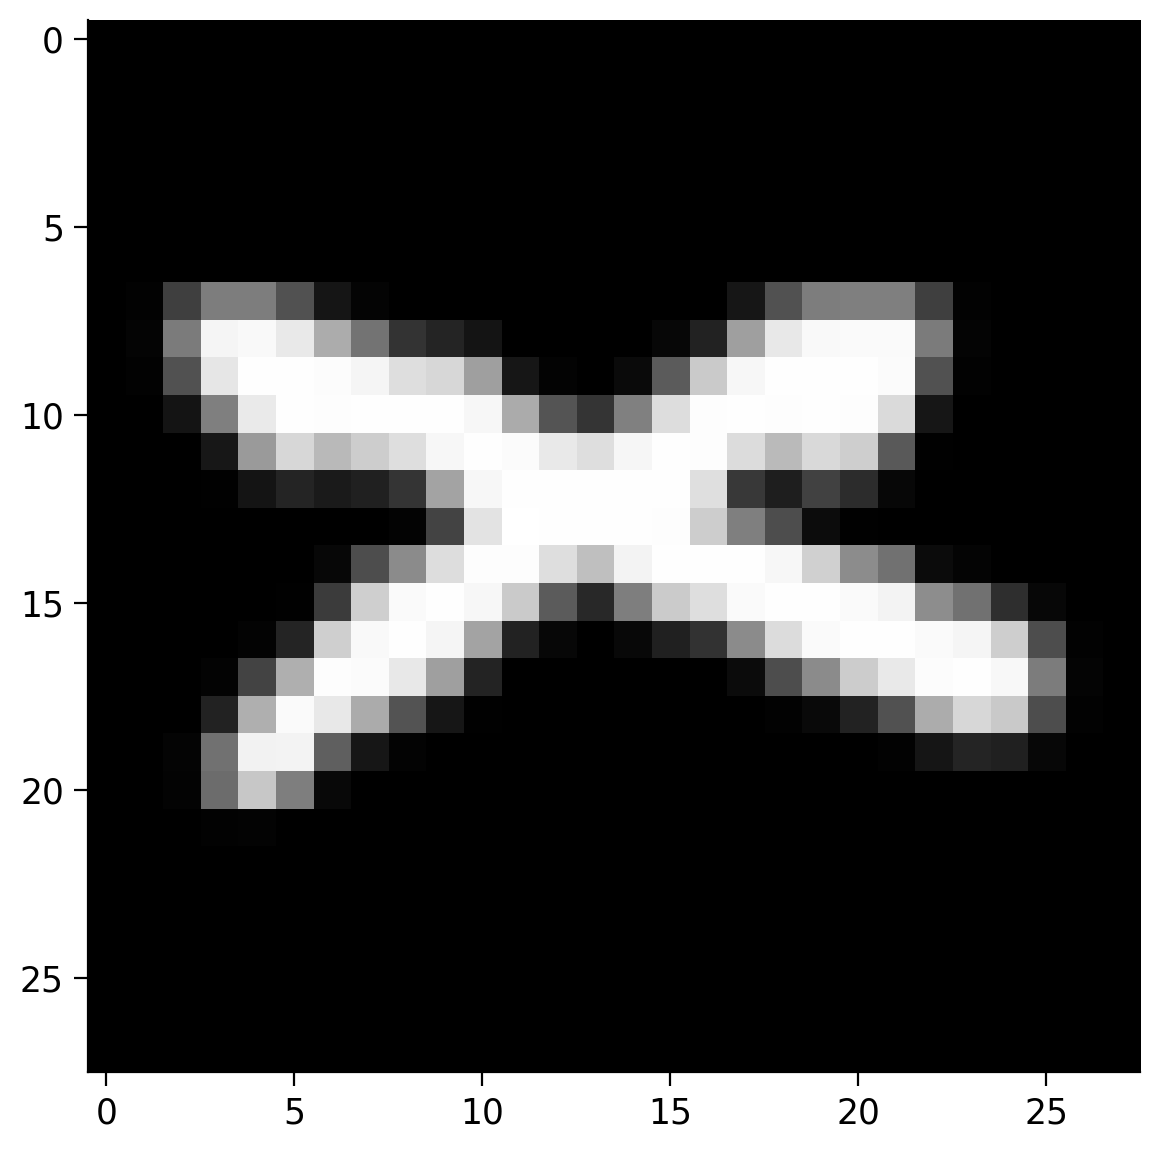


Result: tensor([[0.0025, 0.9975]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Confidence of image being an 'O': 0.0025299726985394955
Confidence of image being an 'X': 0.9974700212478638


In [59]:
# Indice of una imagen en el dataset que corresponde a una X y O
x_img_idx = 11
o_img_idx = 0

print("Input:")
x_img = emnist_train[x_img_idx][0].unsqueeze(dim=0).to(DEVICE)
plt.imshow(emnist_train[x_img_idx][0].reshape(28, 28),
           cmap=plt.get_cmap('gray'))
plt.show()
output = emnist_net(x_img)
result = F.softmax(output, dim=1)
print("\nResult:", result)
print("Confidence of image being an 'O':", result[0, 0].item())
print("Confidence of image being an 'X':", result[0, 1].item())

¡La red está bastante segura de que esta imagen es una \(X\)!

Observa que esto es evidente a partir de la salida de *softmax*, que muestra las probabilidades de que la imagen pertenezca a cada una de las clases. Hay una probabilidad más alta de que pertenezca a la clase 1; es decir, la clase \(X\).

Probemos también la red con una imagen de \(O\).


Input:


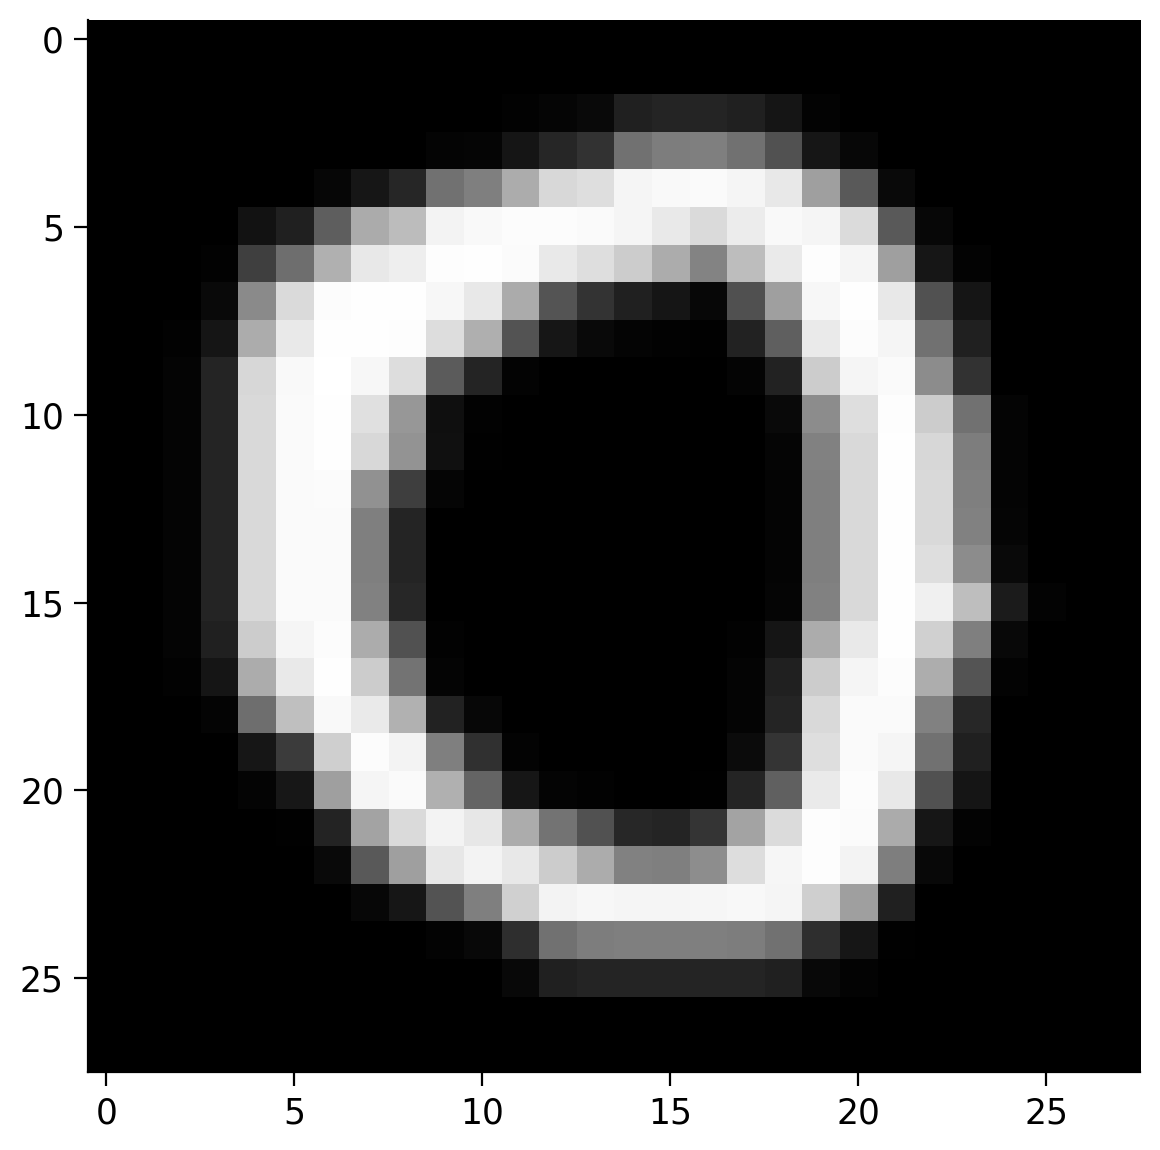


Result: tensor([[9.9974e-01, 2.6190e-04]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Confidence of image being an 'O': 0.9997380375862122
Confidence of image being an 'X': 0.0002619034785311669


In [60]:
print("Input:")
o_img = emnist_train[o_img_idx][0].unsqueeze(dim=0).to(DEVICE)
plt.imshow(emnist_train[o_img_idx][0].reshape(28, 28),
           cmap=plt.get_cmap('gray'))
plt.show()
output = emnist_net(o_img)
result = F.softmax(output, dim=1)
print("\nResult:", result)
print("Confidence of image being an 'O':", result[0, 0].item())
print("Confidence of image being an 'X':", result[0, 1].item())